In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm


plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [4]:
hela_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0091_m6Afinal/pileup.genomic.pkl"
hela_genomic_df = pd.read_pickle(hela_genomic_df)
hela_genomic_df = hela_genomic_df[hela_genomic_df["count_all"] >= 20]
print(hela_genomic_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1  0.018456   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1 -0.000000   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1  0.012951   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.012672   
...                          ...         ...     ...       ...       ...   
chrX:-:8732088    chrX:-:8732088       ANOS1    True         1 -0.000000   
chrX:-:8732091    chrX:-:8732091       ANOS1    True         1  0.066159   
chrX:-:8732104    chrX:-:8732104       ANOS1    True         1 -0.000000   
chrX:-:8732109    chrX:-:8732109       ANOS1    True         1 -0.000000   
chrX:-:8732112    chrX:-:8732112       ANOS1    True         1 -0.000000   

           

In [5]:
hek_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0090_m6Afinal/pileup.genomic.pkl"
hek_genomic_df = pd.read_pickle(hek_genomic_df)
hek_genomic_df = hek_genomic_df[hek_genomic_df["count_all"] >= 20]
print(hek_genomic_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1  0.009356   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1 -0.000000   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1  0.007684   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.007402   
...                          ...         ...     ...       ...       ...   
chrX:-:8732088    chrX:-:8732088       ANOS1    True         1 -0.000000   
chrX:-:8732091    chrX:-:8732091       ANOS1    True         1  0.000000   
chrX:-:8732104    chrX:-:8732104       ANOS1    True         1  0.050544   
chrX:-:8732109    chrX:-:8732109       ANOS1    True         1  0.000000   
chrX:-:8732112    chrX:-:8732112       ANOS1    True         1  0.039708   

           

In [6]:
threshold = 0.48

hela_genomic_df_m6a = hela_genomic_df[hela_genomic_df["pm6a"] > threshold].copy()
hek_genomic_df_m6a = hek_genomic_df[hek_genomic_df["pm6a"] > threshold].copy()

In [7]:
print(hela_genomic_df_m6a)
print(hek_genomic_df_m6a)

                           genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                      
chr10:+:100360903  chr10:+:100360903         SCD    True         1  0.528944   
chr10:+:100363097  chr10:+:100363097         SCD    True         1  0.586329   
chr10:+:100363423  chr10:+:100363423         SCD    True         1  0.689704   
chr10:+:100364038  chr10:+:100364038         SCD    True         1  0.489546   
chr10:+:100364512  chr10:+:100364512         SCD    True         1  1.574561   
...                              ...         ...     ...       ...       ...   
chrX:-:85963894      chrX:-:85963894         CHM    True         1  0.496800   
chrX:-:85963898      chrX:-:85963898         CHM    True         1  0.556856   
chrX:-:85971282      chrX:-:85971282         CHM    True         1  0.542678   
chrX:-:85971349      chrX:-:85971349         CHM    True         1  0.619062   
chrX:-:85971360      chrX:-:85971360    

In [19]:
hek_dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl.m6A.genomic.pkl")
print(hek_dorado_df)

                       genome_id gene_symbol       dom  count_dom  coding
genome_id                                                                
chr10:+:1000680  chr10:+:1000680      GTPBP4  0.142857          7    True
chr10:+:1000681  chr10:+:1000681      GTPBP4  0.004219        474    True
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.004073        491    True
chr10:+:1000685  chr10:+:1000685      GTPBP4  0.017167        466    True
chr10:+:1000688  chr10:+:1000688      GTPBP4  1.000000          1    True
...                          ...         ...       ...        ...     ...
chrX:-:9760794    chrX:-:9760794      GPR143  0.000000          5    True
chrX:-:9760797    chrX:-:9760797      GPR143  0.000000          5    True
chrX:-:9760808    chrX:-:9760808      GPR143  0.250000          4    True
chrX:-:9760817    chrX:-:9760817      GPR143  0.000000          5    True
chrX:-:9760823    chrX:-:9760823      GPR143  0.000000          4    True

[22959784 rows x 5 columns]


In [20]:
hek_label = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/v2Genomic.GP3.depth5_None.twm6astrict.pkl")

In [21]:
print(hek_dorado_df[(hek_dorado_df["dom"] >= 0.43) & (hek_dorado_df["count_dom"] >= 20)]["genome_id"].nunique())

72333


In [22]:
print(hek_genomic_df[(hek_genomic_df["pm6a"] >= 0.712) & (hek_genomic_df["count_dom"] >= 20)]["genome_id"].nunique())

105624


In [23]:
airna_arr = hek_genomic_df[(hek_genomic_df["pm6a"] >= 0.712) & (hek_genomic_df["count_dom"] >= 20)]["genome_id"].unique()
dorado_arr = hek_dorado_df[(hek_dorado_df["dom"] >= 0.43) & (hek_dorado_df["count_dom"] >= 20)]["genome_id"].unique()

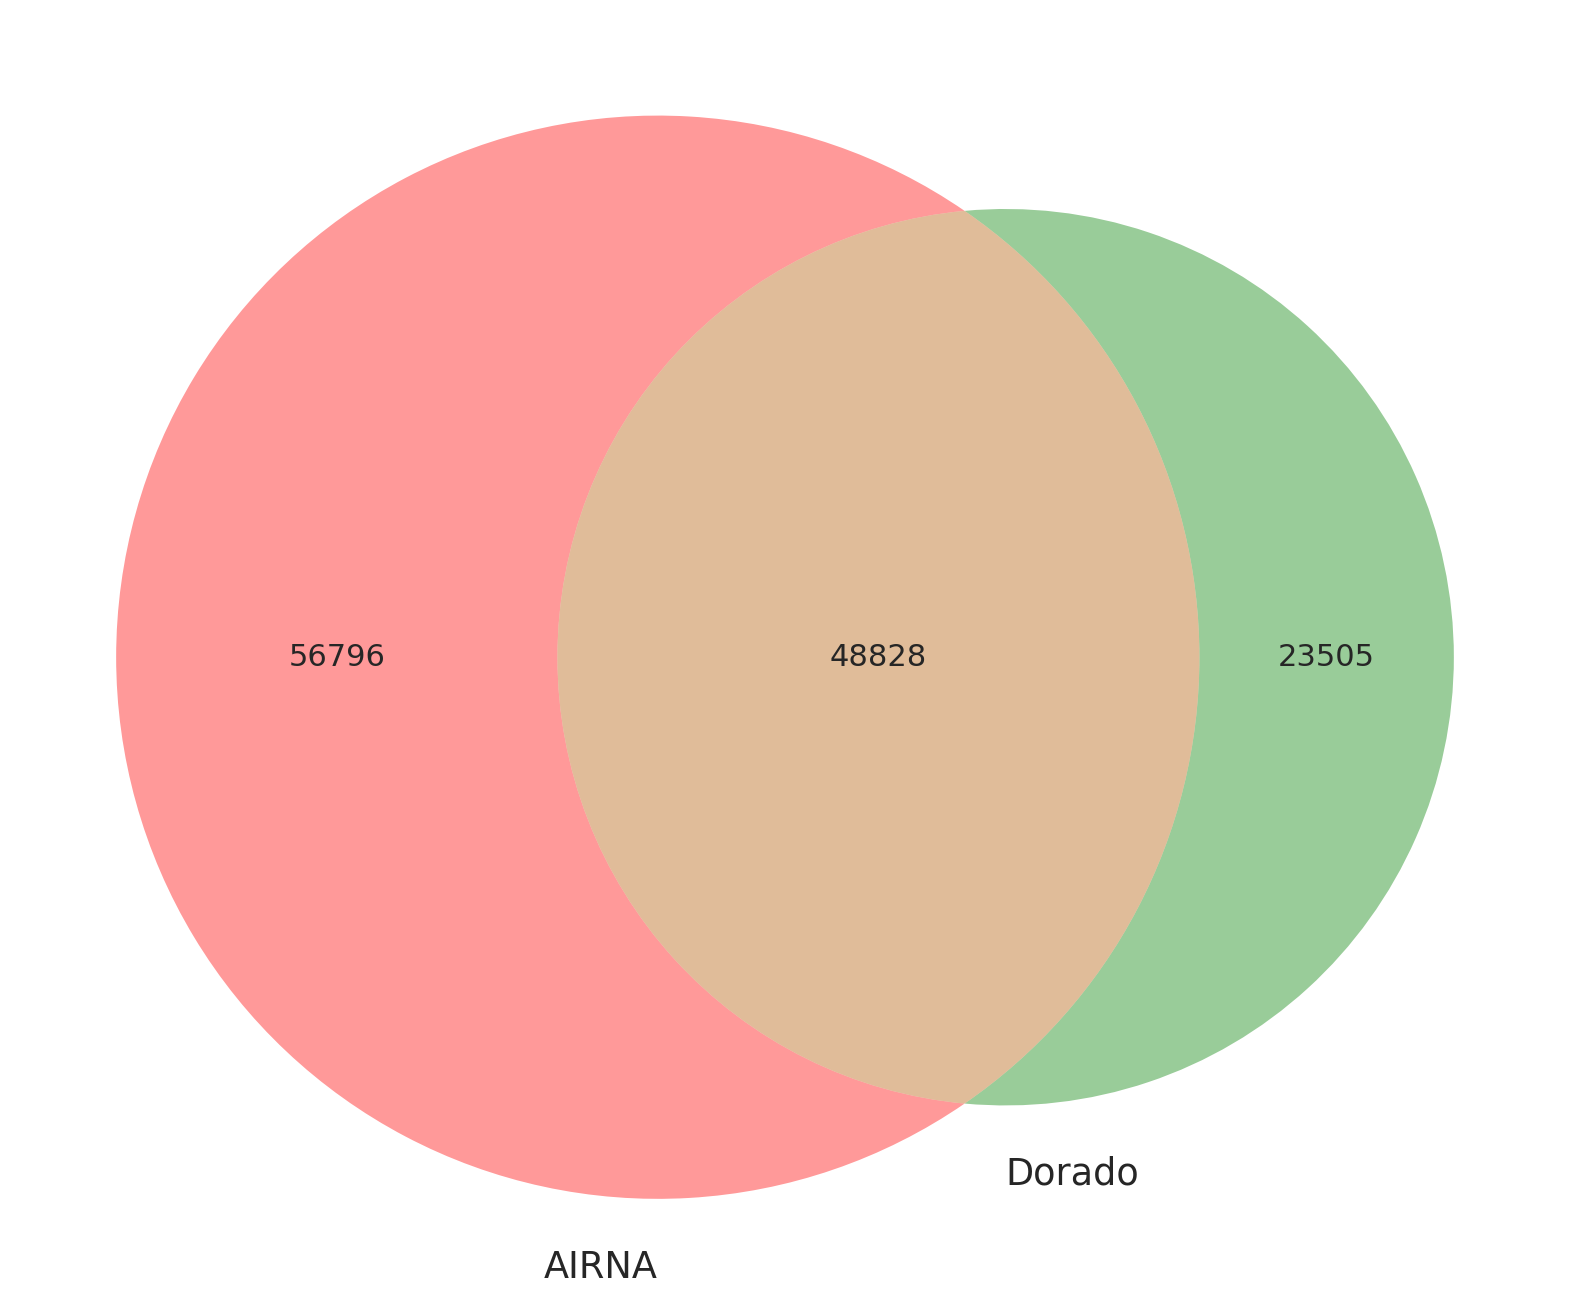

In [24]:
## Plot Venn
import matplotlib_venn as venn
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
## count
venn.venn2([set(airna_arr), set(dorado_arr)], set_labels=("AIRNA", "Dorado"))

plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/venn.pdf", format="pdf")
plt.show()


In [25]:
print(hek_label)

                  id  depth          nmid  pos   5mer  m6A_level  label  \
0       NM_033656:11     10     NM_033656   11  GCACG        0.0      0   
1       NM_033656:16     10     NM_033656   16  GTATG        0.0      0   
2       NM_033656:51     19     NM_033656   51  TGAGA        0.0      0   
3       NM_033656:53     19     NM_033656   53  AGAAG        0.0     -1   
4       NM_033656:54     19     NM_033656   54  GAAGA        0.0      0   
..               ...    ...           ...  ...    ...        ...    ...   
12      NR_003065:61     15     NR_003065   61  TCACC        0.0     -3   
13      NR_003065:68     15     NR_003065   68  TGACT        0.0     -3   
14      NR_003065:72     15     NR_003065   72  TGATG        0.0     -3   
0   NM_001388168:415      6  NM_001388168  415  TTAGG        0.0     -3   
0   NM_001393570:470      6  NM_001393570  470  TCAGG        0.0     -3   

           genome_id  drach  
0   chr21:-:39313620  False  
1   chr21:-:39313615  False  
2   chr21

In [26]:
hek_eval = hek_genomic_df_m6a.merge(hek_label, on="genome_id", how="left")

In [27]:
print(hek_eval)

                genome_id gene_symbol  coding       dom  count_dom  \
0       chr10:+:100364512         SCD    True  0.359959       2942   
1       chr10:+:100364569         SCD    True  0.218364       2995   
2       chr10:+:100381333    OLMALINC   False  0.155556        135   
3       chr10:+:100388236    OLMALINC   False  0.180000        100   
4       chr10:+:100388266    OLMALINC   False  0.339450        109   
...                   ...         ...     ...       ...        ...   
261108    chrX:-:85864614         CHM    True  0.142857         28   
261109    chrX:-:85864679         CHM    True  0.576923         26   
261110    chrX:-:85864679         CHM    True  0.576923         26   
261111    chrX:-:85956342         CHM    True  0.200000         20   
261112    chrX:-:85971260         CHM    True  0.481481         27   

        logsum_1_p_pos  count_pos  count_all  isoforms      pm6a  \
0         -3305.878662        910       3040         1  1.698536   
1         -1664.377441 

In [28]:
print(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}))

                   coding  drach
genome_id                       
chr10:+:100364512    True   True
chr10:+:100364569    True   True
chr10:+:100381333   False   True
chr10:+:100388236   False  False
chr10:+:100388266   False   True
...                   ...    ...
chrX:-:85864587      True   True
chrX:-:85864614      True   True
chrX:-:85864679      True   True
chrX:-:85956342      True   True
chrX:-:85971260      True   True

[107081 rows x 2 columns]


In [29]:
## Count DRACH+Coding, DRACH+Noncoding, Non-DRACH+Coding, Non-DRACH+Noncoding
print(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()/hek_eval["genome_id"].nunique())

print(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size())
print(sum(hek_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()))

coding  drach
False   False    0.006546
        True     0.050793
True    False    0.084870
        True     0.857790
dtype: float64
coding  drach
False   False      701
        True      5439
True    False     9088
        True     91853
dtype: int64
107081


[90861, 5170, 664, 8929]


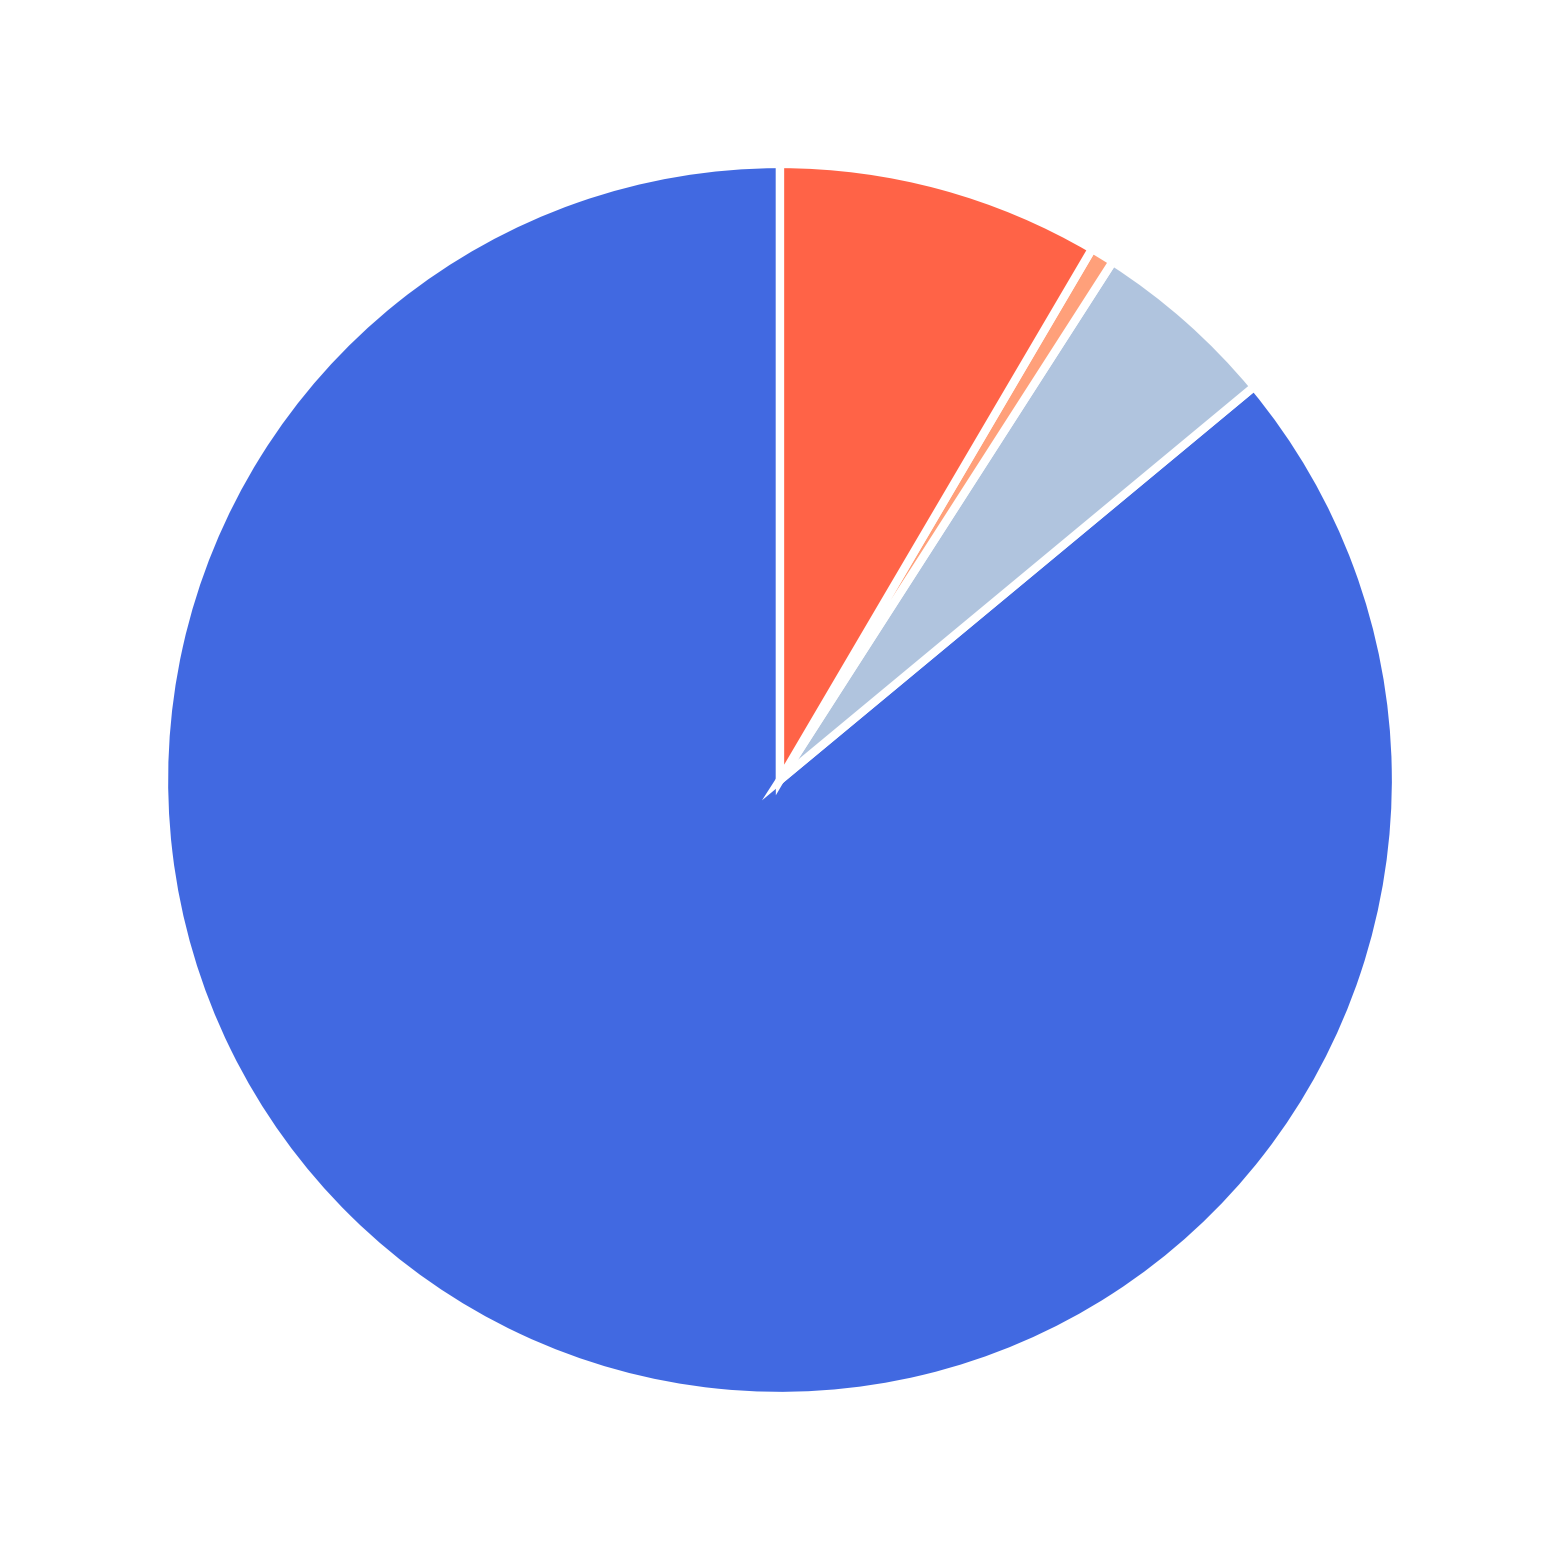

In [30]:
## Plot Pie chart
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [90861, 5170, 664, 8929]
print(y)
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon',  'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_hek.pdf", format="pdf")
plt.show()

In [31]:
hela_label = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/v2Genomic.v2Genomic.GP3.depth5_None.twm6astrict.pkl")
print(hela_label)

               id  depth       nmid  pos   5mer  m6A_level  label  \
0    NM_033656:51      6  NM_033656   51  TGAGA        0.0      0   
1    NM_033656:53      6  NM_033656   53  AGAAG        0.0     -1   
2    NM_033656:54      6  NM_033656   54  GAAGA        0.0      0   
3    NM_033656:56      6  NM_033656   56  AGAGG        0.0      0   
4    NM_033656:61      6  NM_033656   61  GGACG        0.0     -1   
..            ...    ...        ...  ...    ...        ...    ...   
3   NR_120423:104      6  NR_120423  104  GAATC        0.0     -3   
4   NR_120423:108      6  NR_120423  108  CCAGA        0.0     -3   
5   NR_120423:110      6  NR_120423  110  AGAGT        0.0     -3   
6   NR_120423:113      6  NR_120423  113  GTAGT        0.0     -3   
7   NR_120423:127      6  NR_120423  127  CTAGT        0.0     -3   

           genome_id  drach  
0   chr21:-:39313580  False  
1   chr21:-:39313578  False  
2   chr21:-:39313577  False  
3   chr21:-:39313575  False  
4   chr21:-:39313570 

In [32]:
hela_eval = hela_genomic_df_m6a.merge(hela_label, on="genome_id", how="left")
print(hela_eval)

                genome_id gene_symbol  coding       dom  count_dom  \
0       chr10:+:100364512         SCD    True  0.315391       3827   
1       chr10:+:100364569         SCD    True  0.177046       3886   
2       chr10:+:100388266    OLMALINC   False  0.257235        311   
3       chr10:+:100388308    OLMALINC   False  0.392086        278   
4       chr10:+:100548246      HIF1AN    True  0.770115         87   
...                   ...         ...     ...       ...        ...   
226356    chrX:-:85864753         CHM    True  0.131579         38   
226357    chrX:-:85864753         CHM    True  0.131579         38   
226358    chrX:-:85956342         CHM    True  0.222222         27   
226359    chrX:-:85956342         CHM    True  0.222222         27   
226360    chrX:-:85971360         CHM    True  0.238095         21   

        logsum_1_p_pos  count_pos  count_all  isoforms      pm6a  \
0         -3840.107666       1062       3948         1  1.565750   
1         -1921.157959 

In [33]:
print(hela_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size())
print(hela_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()/sum(hela_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()))
print(sum(hela_eval.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()))

coding  drach
False   False      584
        True      4463
True    False     7958
        True     79487
dtype: int64
coding  drach
False   False    0.006314
        True     0.048253
True    False    0.086040
        True     0.859393
dtype: float64
92492


In [34]:
fdr_thr = 0.55

print(np.sum(hela_genomic_df["pm6a"] > fdr_thr))
print(np.sum(hek_genomic_df["pm6a"] > fdr_thr))

hela_genomic_df_m6a_fdr = hela_genomic_df[hela_genomic_df["pm6a"] > fdr_thr].copy()
hek_genomic_df_m6a_fdr= hek_genomic_df[hek_genomic_df["pm6a"] > fdr_thr].copy()
hela_eval_fdr = hela_genomic_df_m6a_fdr.merge(hela_label, on="genome_id", how="left")
hek_eval_fdr = hek_genomic_df_m6a_fdr.merge(hek_label, on="genome_id", how="left")

108303
125916


In [35]:

print(np.sum([hela_genomic_df["pm6a"] > 0.55]))
print(np.sum([hek_genomic_df["pm6a"] > 0.55]))

108303
125916


In [36]:
## Count DRACH+Coding, DRACH+Noncoding, Non-DRACH+Coding, Non-DRACH+Noncoding
print(hek_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()/hek_eval_fdr["genome_id"].nunique())

print(hek_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["drach"]).size())
print(sum(hek_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["drach"]).size()))

coding  drach
False   False    0.007735
        True     0.049676
True    False    0.100631
        True     0.841958
dtype: float64
drach
False     13645
True     112271
dtype: int64
125916


In [37]:
## Count DRACH+Coding, DRACH+Noncoding, Non-DRACH+Coding, Non-DRACH+Noncoding
print(hela_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()/hela_eval_fdr["genome_id"].nunique())

print(hela_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["drach"]).size())
print(sum(hela_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach": "max"}).groupby(["coding", "drach"]).size()))

coding  drach
False   False    0.007581
        True     0.047164
True    False    0.101493
        True     0.843762
dtype: float64
drach
False    11813
True     96490
dtype: int64
108303


[79487, 4463, 584, 7958]


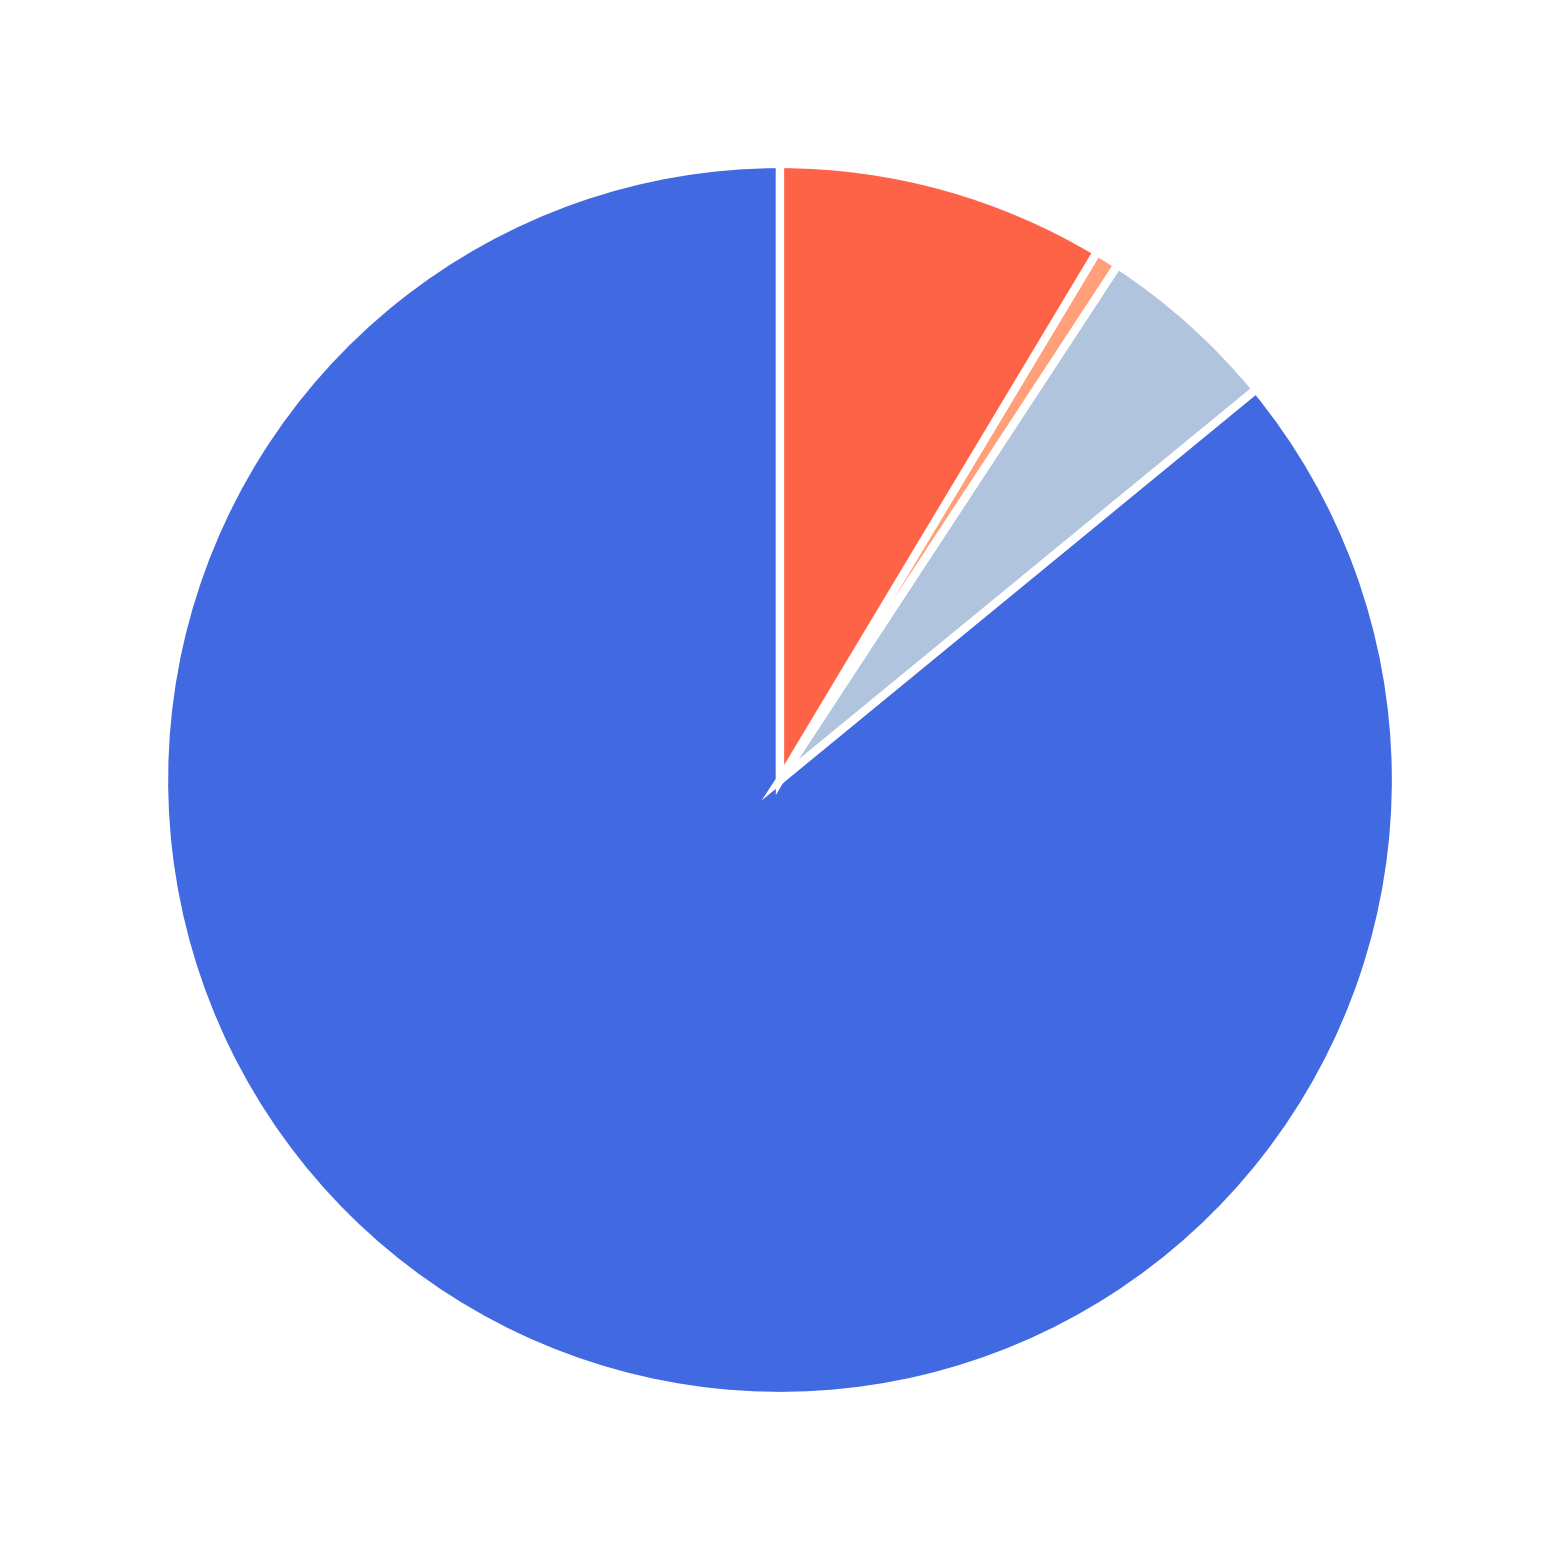

In [38]:
## Plot Pie chart
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [79487, 4463, 584, 7958]
print(y)
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon',  'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_hela.pdf", format="pdf")
plt.show()

In [39]:
def drach_ed(seq):
    ed = 0
    if not seq[0] in ["A", "G", "T", "U"]:
        ed += 1
    if not seq[1] in ["G", "A"]:
        ed += 1
    if not seq[2] == "A":
        ed += 1
    if not seq[3] == "C":
        ed += 1
    if not seq[4] in ["A", "C", "T", "U"]:
        ed += 1
    return ed
        
        


In [40]:
hek_eval["drach_ed"] = hek_eval["5mer"].apply(drach_ed)
print(hek_eval)

                genome_id gene_symbol  coding       dom  count_dom  \
0       chr10:+:100364512         SCD    True  0.359959       2942   
1       chr10:+:100364569         SCD    True  0.218364       2995   
2       chr10:+:100381333    OLMALINC   False  0.155556        135   
3       chr10:+:100388236    OLMALINC   False  0.180000        100   
4       chr10:+:100388266    OLMALINC   False  0.339450        109   
...                   ...         ...     ...       ...        ...   
261108    chrX:-:85864614         CHM    True  0.142857         28   
261109    chrX:-:85864679         CHM    True  0.576923         26   
261110    chrX:-:85864679         CHM    True  0.576923         26   
261111    chrX:-:85956342         CHM    True  0.200000         20   
261112    chrX:-:85971260         CHM    True  0.481481         27   

        logsum_1_p_pos  count_pos  count_all  isoforms      pm6a  \
0         -3305.878662        910       3040         1  1.698536   
1         -1664.377441 

In [41]:
agg_df = hek_eval.groupby("genome_id").agg({"coding": "max", "drach_ed": "max"})
print(agg_df)

                   coding  drach_ed
genome_id                          
chr10:+:100364512    True         0
chr10:+:100364569    True         0
chr10:+:100381333   False         0
chr10:+:100388236   False         1
chr10:+:100388266   False         0
...                   ...       ...
chrX:-:85864587      True         0
chrX:-:85864614      True         0
chrX:-:85864679      True         0
chrX:-:85956342      True         0
chrX:-:85971260      True         0

[107081 rows x 2 columns]


In [42]:
print(agg_df["drach_ed"].value_counts())

drach_ed
0    97239
1     9558
2      228
3       41
4       15
Name: count, dtype: int64


In [43]:
hek_eval_fdr["drach_ed"] = hek_eval["5mer"].apply(drach_ed)
agg_df = hek_eval_fdr.groupby("genome_id").agg({"coding": "max", "drach_ed": "max"})
print(agg_df["drach_ed"].value_counts())

drach_ed
0.0    93355
1.0    12952
2.0      285
3.0       52
4.0       19
Name: count, dtype: int64


In [44]:
print(hek_eval[hek_eval["drach_ed"] == 4]["5mer"].value_counts())

5mer
CCATG    15
CCAGG     6
CCAAG     5
CTATG     4
CTAAG     1
CTAGG     1
Name: count, dtype: int64


In [45]:
print(hek_eval[hek_eval["drach_ed"] > 0]["5mer"].value_counts() / len(hek_eval[hek_eval["drach_ed"]  > 0]))
print(hek_eval[hek_eval["drach_ed"] > 0]["5mer"].value_counts())

5mer
GGACG    0.341685
GGATT    0.177739
AGACG    0.073284
GTACT    0.072962
GAACG    0.041056
           ...   
CAAGA    0.000046
GCAGG    0.000046
TGAGG    0.000046
GTATG    0.000046
ACATT    0.000046
Name: count, Length: 153, dtype: float64
5mer
GGACG    7432
GGATT    3866
AGACG    1594
GTACT    1587
GAACG     893
         ... 
CAAGA       1
GCAGG       1
TGAGG       1
GTATG       1
ACATT       1
Name: count, Length: 153, dtype: int64


In [46]:
print(len(hek_eval[hek_eval["drach_ed"] > 0]))
print(len(hek_eval[hek_eval["drach_ed"] > 3]))

21751
32


In [47]:
32/21751

0.0014711967265872833

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


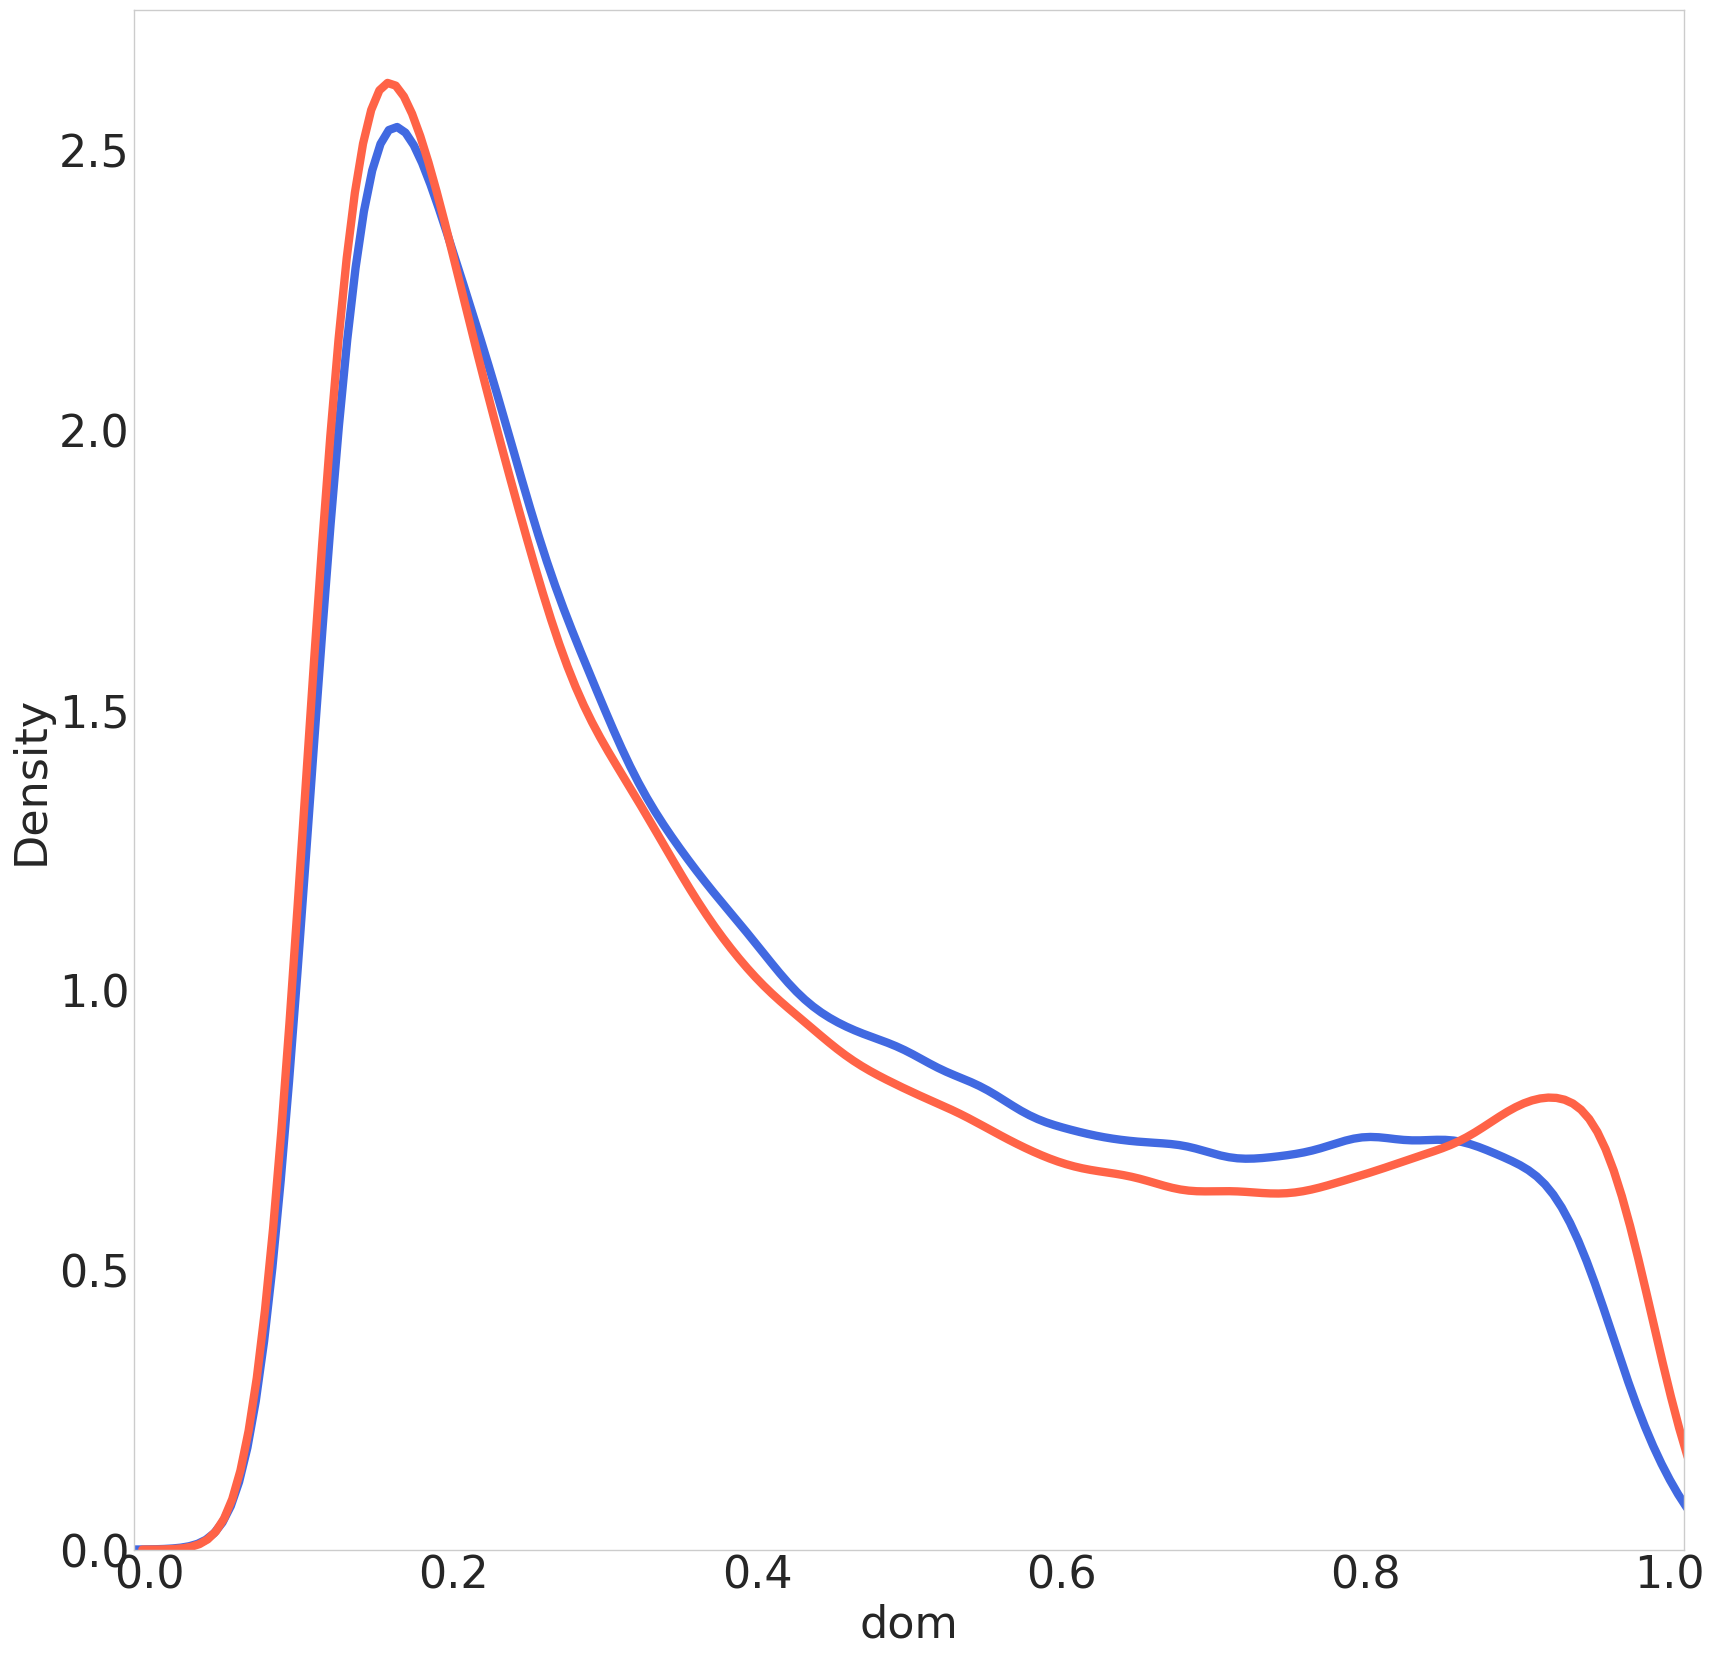

In [48]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval_fdr, x="dom", ax=ax, fill=False, levels=100, color="royalblue", alpha=1.0)
sns.kdeplot(data=hela_eval_fdr, x="dom", ax=ax, fill=False, levels=100, color="tomato",  alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_distribution.pdf", format="pdf")
plt.show()

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


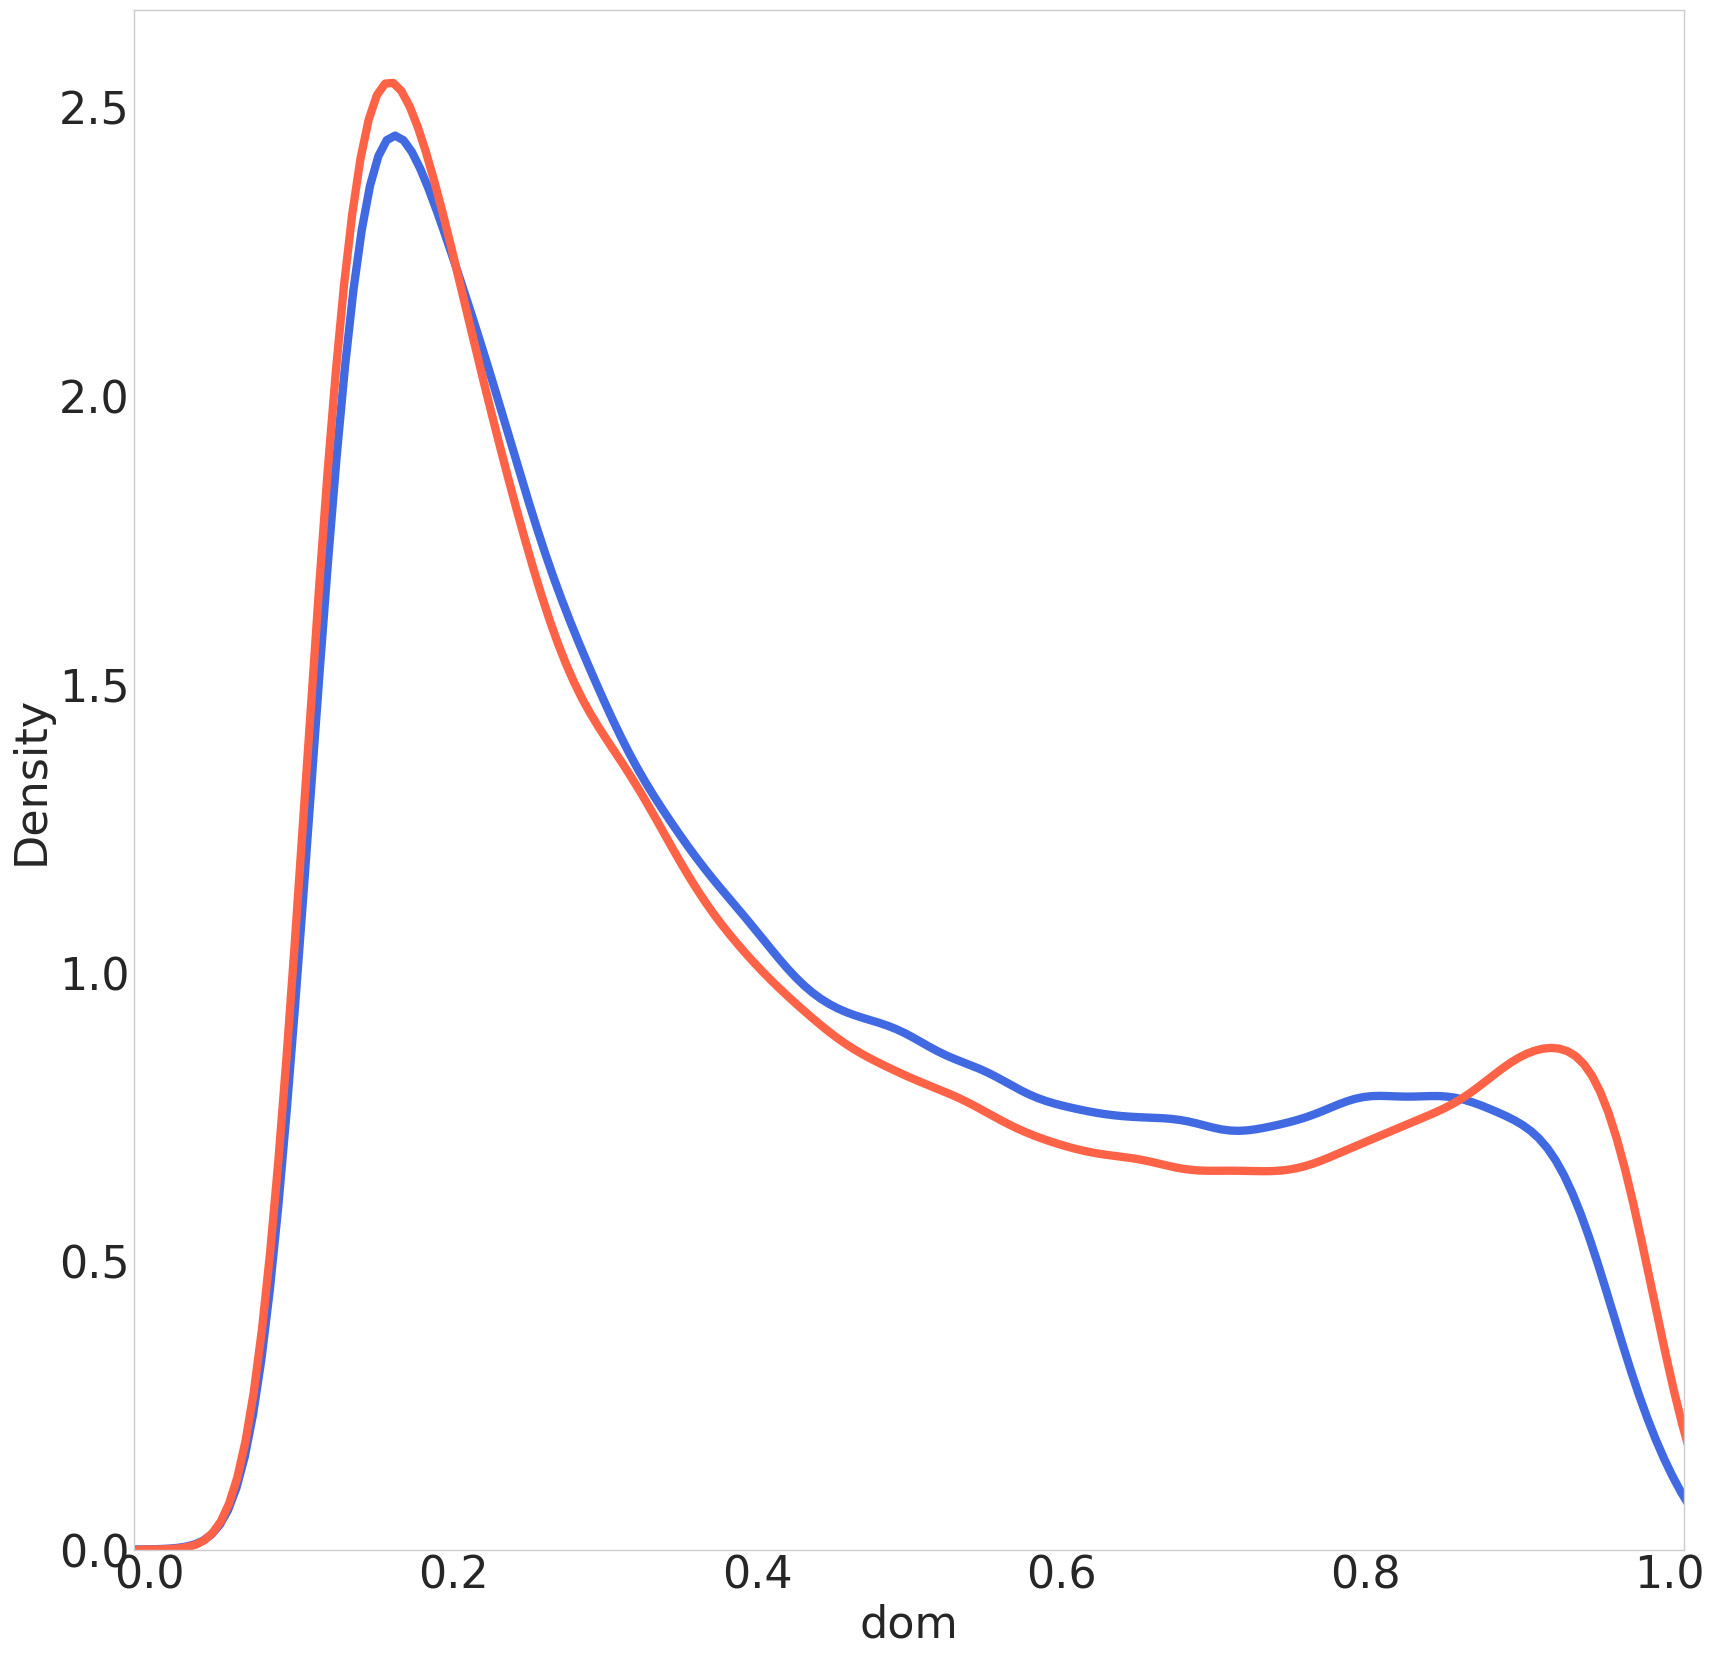

In [49]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval_fdr[hek_eval_fdr["drach"]], x="dom", ax=ax, fill=False, levels=100, color="royalblue",  alpha=1.0)
sns.kdeplot(data=hela_eval_fdr[hela_eval_fdr["drach"]], x="dom", ax=ax, fill=False, levels=100, color="tomato",   alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_drach.pdf", format="pdf")
plt.show()

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


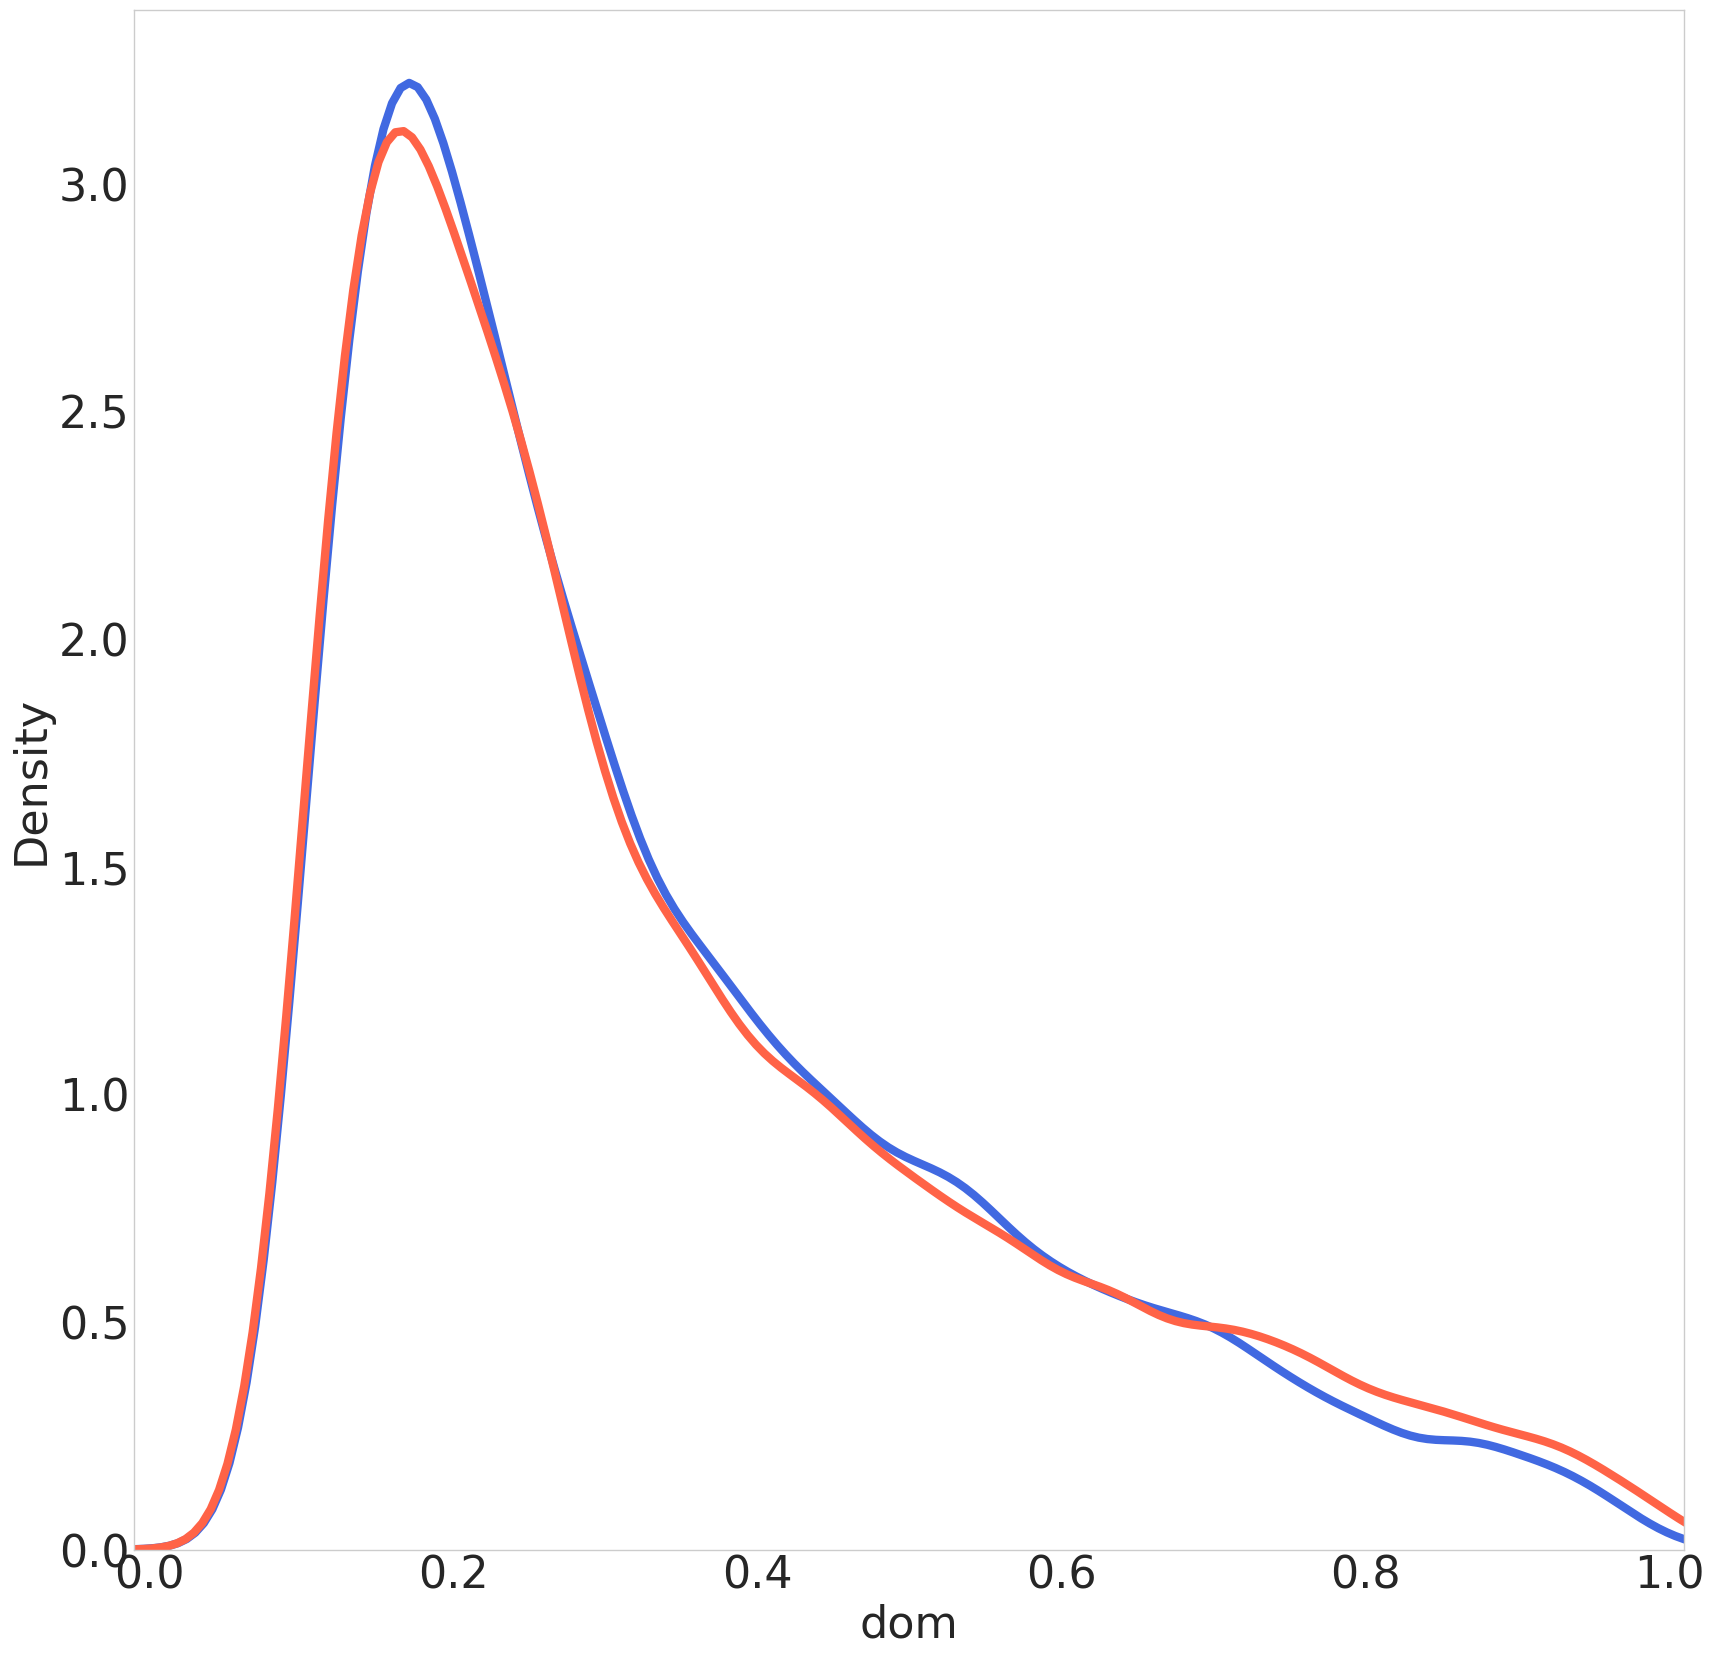

In [50]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval_fdr[~hek_eval_fdr["drach"]], x="dom", ax=ax, fill=False, levels=100, color="royalblue",  alpha=1.0)
sns.kdeplot(data=hela_eval_fdr[~hela_eval_fdr["drach"]], x="dom", ax=ax, fill=False, levels=100, color="tomato",   alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_nondrach.pdf", format="pdf")
plt.show()

In [51]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif-ON0091_m6A/pileup.npz"
with np.load(hela_df, allow_pickle=True) as data:
    hela_df = pd.DataFrame({key: data[key] for key in data.keys()})
hela_df = hela_df[hela_df["count_all"] >= 20]
print(hela_df)

hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_psum/pileup.npz"
with np.load(hek_df, allow_pickle=True) as data:
    hek_df = pd.DataFrame({key: data[key] for key in data.keys()})
hek_df = hek_df[hek_df["count_all"] >= 20]
print(hek_df)

                label_id     p_sum  logsum_1_p_pos       dom  count_all  \
0         NM_000016:1000  0.843626             0.0  0.000000        310   
1         NM_000016:1008  1.863539             0.0  0.006452        310   
2         NM_000016:1009  2.171798             0.0  0.003247        311   
3         NM_000016:1010  3.194226             0.0  0.003236        313   
4         NM_000016:1014  4.851071             0.0  0.006557        312   
...                  ...       ...             ...       ...        ...   
26478388   NR_184306:966  0.558527             0.0  0.000000         20   
26478389   NR_184306:967  0.879458             0.0  0.000000         20   
26478391   NR_184306:979  2.395881             0.0  0.058824         20   
26478392    NR_184306:98  5.731736             0.0  0.160000         28   
26478393   NR_184306:984  0.717068             0.0  0.050000         20   

          count_dom  count_pos  
0               308          0  
1               310          0  


In [13]:
from Bio import SeqIO
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {x.split(".")[0]: y for x, y in fasta_dict.items()}
a_count_dict = {x: y.seq.count("A") for x, y in fasta_dict.items()}

In [10]:
## Draw Discrepancy
geneid_table = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/res/ref/GRCh38_latest_genomic.convert_table.pkl")
convert_dict = dict(zip(geneid_table["transcript_id"], geneid_table["gene_id"]))

In [14]:
a_count_df = pd.DataFrame(a_count_dict.items(), columns=["refseq", "a_count"])
a_count_df["gene_id"] = a_count_df["refseq"].map(convert_dict)
print(a_count_df)

          refseq  a_count       gene_id
0      NM_000014     1245           A2M
1      NM_000015      414          NAT2
2      NM_000016      729         ACADM
3      NM_000017      344         ACADS
4      NM_000018      476        ACADVL
...          ...      ...           ...
87405  NR_184402     1418         ACTN2
87406  NR_184444     1436        ADGRF2
87407  NR_184445     1401        ADGRF2
87408  NR_184562      361  LOC100505874
87409  NR_184563     1834  LOC100505874

[87410 rows x 3 columns]


In [15]:
a_count_df = a_count_df.groupby("gene_id").agg({"a_count": "mean"})

In [16]:
print(a_count_df)

              a_count
gene_id              
A1BG       623.000000
A1BG-AS1   524.000000
A1CF      2998.875000
A2M       1247.500000
A2M-AS1    608.333333
...               ...
ZYG11A    1036.500000
ZYG11B    2371.000000
ZYX        401.666667
ZZEF1     2774.000000
ZZZ3      1953.785714

[28964 rows x 1 columns]


In [18]:
hela_m6a_count = hela_genomic_df_m6a.groupby("gene_symbol").size()
hek_m6a_count = hek_genomic_df_m6a.groupby("gene_symbol").size()

print(hela_m6a_count)
print(hek_m6a_count)

gene_symbol
A4GALT    20
AACS       5
AADAT      7
AAGAB      3
AAK1       9
          ..
ZYG11A    12
ZYG11B     1
ZYX        2
ZZEF1     32
ZZZ3      30
Length: 10236, dtype: int64
gene_symbol
A1BG         1
A1BG-AS1    19
A4GALT      22
AACS         5
AADAT        9
            ..
ZYG11A      14
ZYG11B       6
ZYX          1
ZZEF1       36
ZZZ3        30
Length: 11384, dtype: int64


In [20]:
hela_m6a_density = pd.DataFrame(hela_m6a_count, columns=["m6A_count"]).merge(a_count_df, left_index=True, right_index=True)
hek_m6a_density = pd.DataFrame(hek_m6a_count, columns=["m6A_count"]).merge(a_count_df, left_index=True, right_index=True)

hela_m6a_density["density"] = hela_m6a_density["m6A_count"]/hela_m6a_density["a_count"]
hek_m6a_density["density"] = hek_m6a_density["m6A_count"]/hek_m6a_density["a_count"]

print(hela_m6a_density)
print(hek_m6a_density)

        m6A_count      a_count   density
A4GALT         20   296.000000  0.067568
AACS            5   695.555556  0.007188
AADAT           7   673.750000  0.010390
AAGAB           3   895.000000  0.003352
AAK1            9  4526.000000  0.001989
...           ...          ...       ...
ZYG11A         12  1036.500000  0.011577
ZYG11B          1  2371.000000  0.000422
ZYX             2   401.666667  0.004979
ZZEF1          32  2774.000000  0.011536
ZZZ3           30  1953.785714  0.015355

[10236 rows x 3 columns]
          m6A_count      a_count   density
A1BG              1   623.000000  0.001605
A1BG-AS1         19   524.000000  0.036260
A4GALT           22   296.000000  0.074324
AACS              5   695.555556  0.007188
AADAT             9   673.750000  0.013358
...             ...          ...       ...
ZYG11A           14  1036.500000  0.013507
ZYG11B            6  2371.000000  0.002531
ZYX               1   401.666667  0.002490
ZZEF1            36  2774.000000  0.012978
ZZZ3     

In [37]:
## 30 most heavily m6A modified genes
print("\n".join(list(hek_m6a_density.sort_values("m6A_count", ascending=False)[:200].index)))

AHNAK
FAT1
SACS
DIDO1
KMT2A
EPPK1
KIAA1549
SPEN
SON
ANKRD33B
TBC1D16
MKI67
ALMS1
H6PD
TUG1
ARHGAP35
ING5
FAT4
PLXNA2
ANKRD11
PEAK1
SMCR8
CELSR2
ERC1
VCAN
SETX
MACF1
TASOR2
ZNF646
PCDH7
LINC00205
MYORG
ZNF318
RESF1
LMTK2
CELSR1
IRS1
IGF1R
BPTF
ZCCHC14
ZBED4
SFMBT2
ZKSCAN2
PTCHD1
MGA
SRCAP
NSD1
PHF3
ZNF618
ZNF778
PCDH9
KAT6A
NRIP1
CHST3
RANBP6
PLEC
HTT
KIF1B
SETD1B
SYNM
ZNF608
ZNF12
GLI2
ZNF292
PRR14L
GOLGB1
ERCC6L2
TENM3
ZNF629
ZNF142
RLF
CENPF
ZBTB39
ARHGAP21
ZNF518B
ASXL1
C14orf132
ADNP2
SHROOM3
RNF213
ARSJ
KIAA1549L
NUTM2E
DISP1
C15orf39
SALL3
FOXK2
EME2
RAI1
HEG1
ZBED1
RBM15B
RANBP2
PCDH20
SYNRG
HEATR6
TMEM132E
SETD2
TCF20
PKD1
LMLN
SEC16A
KMT2D
DAG1
XIST
AP5B1
MED13
TSHZ1
KCNQ1OT1
ZBTB21
LINC01145
CCDC57
ARHGEF5
WDR81
TSC22D1
CNNM2
MICAL3
CDK13
SLC22A23
BTBD7
LOC100129034
DCHS1
FOXO3
TNRC6A
SCAND3
CEP350
BMF
MTCL1
TPPP
ZNF516
CAMSAP1
GDF11
EPHA4
REV3L
ARHGEF17
PRAG1
AHDC1
DCTN5
BRWD1
CLEC16A
POLR1A
RBM12B
SH3BP4
FAM66B
LRFN3
CHSY3
SLX4
NDST1
ADCY9
SH3PXD2B
JCAD
ABHD15
ZNF521
PLEKHG

In [40]:
## 30 most heavily m6A modified genes
print("\n".join(list(hela_m6a_density.sort_values("m6A_count", ascending=False)[:200].index)))

AHNAK2
AHNAK
RNF213
EPPK1
IGSF10
FAT1
DIDO1
SON
TUG1
KIAA1549
TBC1D16
ZNF469
MKI67
INF2
PLEC
ZNF646
ZCCHC14
ZBTB38
ARHGAP35
CELSR1
DAG1
SLITRK5
ZNF318
SMCR8
PRECSIT
ERC1
MYORG
IGF1R
MGA
IRS1
ANKRD11
MYOCD
TASOR2
TANC2
FAT4
MPRIP
KCNQ1OT1
SPEN
ASXL1
KIF1B
ZBED4
AHDC1
NRIP1
CHST3
ING5
SRCAP
CELSR3
RANBP6
KLHL5
PHF3
BPTF
PKD1
BCL9L
TSHZ2
ZNF12
CENPF
ARHGAP21
DISP1
PDCD6-AHRR
CELSR2
GLI2
MUC16
ADNP2
MICAL3
TMEM184A
SLITRK4
SYNM
SETD2
SNX29
WDR81
SEC16A
FOXK2
ADCY9
TSHZ1
NSD1
RBM12B
ITPRIP
RAI1
ZNF629
PCDH7
CDK13
RBM15B
TNS3
VCPIP1
SH3PXD2A
SH3BP4
SH3PXD2B
PRAG1
SETD1B
AP5B1
LOC100129034
HS6ST3
C15orf39
MN1
SAMD9
HEG1
ZBED1
NSD2
RBBP6
CAMSAP1
TCF20
KMT2D
ARHGEF5
SACS
URGCP
ATMIN
TNRC6A
ARID1A
CLEC16A
CHSY3
SETX
KMT5B
CDCP1
PLEKHG2
TADA2B
ZNF398
NCOA6
ZNF721
ARSJ
ZNFX1
AKAP13
TNRC18
ARHGEF17
ICE1
BACH1
ERCC6
PAQR8
ZNF281
KMT2E
ZNF776
BMF
BCL9
GON4L
IGSF3
KIAA2026
NDST1
ABHD15
PCDHAC2
MSL2
KLHL9
ABL1
RLF
MED13
SLX4
RANBP2
THAP12
URB2
LRRC8D
NKRF
KLF13
CNNM2
TNKS1BP1
LRFN3
PIP5K1C
LUZP1
HUNK
K

In [36]:
## 30 most heavily m6A modified genes
print("\n".join(list(hek_m6a_density.sort_values("density", ascending=False)[:200].index)))

DISP1
EXD3
ADAT3
C7orf50
ING5
SLC39A3
FAAP20
PWWP2B
MC1R
LRFN4
MFSD5
SDHAF1
MPDU1-AS1
UFSP1
HPS6
DNASE1
OXLD1
ASH1L-AS1
FJX1
ZFTRAF1
C19orf73
ARTN
SSR4P1
UQCC4
THAP3
B3GALT6
BORCS8
RPRML
FAM110A
EEF1D
S1PR1
DEXI
CPTP
LINC01145
A4GALT
SCO2
LARRPM
TXNDC12
OXCT2
TIMM29
JPH3
DSP-AS1
CCDC85B
H4C15
TMEM203
SLC25A29
NCBP2AS2
HMX1
CHST14
KCNJ4
CITED4
TMEM121
C15orf39
GP1BB
LRFN1
TMEM115
MYCL
CYBC1
IMP3
ZFP64
RALY-AS1
FNDC10
DOLK
WDR81
ABHD15
ZNF837
MRPS12
ZSCAN2
TUBB6
ZNF865
HDHD3
RTL8A
TICAM1
C11orf68
EMC6
KCNG1
BLOC1S4
RNF26
ZNF324B
PLEKHF1
KCTD11
LOC101928120
CEBPA-DT
RIOX1
TUSC1
ARMC7
FRAT1
SPATA33
C11orf24
SLC35A4
CHPF2
IER3
TSHZ3
H2AX
ZNF566-AS1
DIDO1
PRRT4
RNU6-7
RNU6-8
ZNF581
RTN4R
CSF1
LINC00680
LRRN2
GATA4
SLC22A23
UCN
PAQR4
LBX2-AS1
CANT1
URGCP
SLC16A13
ADORA2B
MISP3
TMEM171
WDR6
BTG3-AS1
LOC100129534
RAB40C
ZNF503
HAPSTR2
FKBPL
TMEM37
ARL17A
B3GALT4
PTRH2
LRFN3
TMEM177
RTN4RL1
C6orf226
MYL5
FZD9
WTAP
LINGO1
ZBTB11-AS1
EMILIN3
KLHL25
SPRY1
LINC01547
PRRT3
FKRP
GEMIN4
WNT6
HOXD4
CILP

In [35]:
## 30 most heavily m6A modified genes
print("\n".join(list(hela_m6a_density.sort_values("density", ascending=False)[:200].index)))

DISP1
MUC1
EXD3
ADAT3
C7orf50
SLC39A3
FAAP20
LRFN4
MC1R
LINC00473
PWWP2B
MFSD5
COA1
ARTN
SDHAF1
FJX1
ING5
INF2
OXLD1
CITED4
CDC42EP2
MPDU1-AS1
HPS6
B3GALT6
CLDN4
SSR4P1
RTL8A
CPTP
RAB42
H4C15
LRFN1
TMEM121
IMP3
SLC25A29
WDR81
FRAT1
UQCC4
AMH
TIMM29
EEF1D
FAM110A
BLOC1S4
TXNDC12
VASN
TMEM203
CHST14
NCBP2AS2
URB1-AS1
TICAM1
BDKRB1
TMEM115
TRABD2A
HRCT1
ZFP64
ZNF865
FNDC10
SCO2
BORCS8
UFSP1
RNF26
LINC00680
DPM2
A4GALT
CYBC1
C11orf68
C15orf39
DIDO1
NUDT18
CCDC85B
RTN4R
KCTD11
RIOX1
MRGPRF
ABHD15
SLITRK5
SGSH
HDHD3
DOLK
CHPF2
VPS9D1-AS1
IER3
DEXI
LOC642361
PAQR4
FKRP
CDCA3
SLC9A3-AS1
ZNF581
CANT1
ARMC7
FOXD2-AS1
URGCP
ACTL10
DAG1
MFSD3
TUSC1
ARL4D
WTAP
KCNG1
ANXA2R-OT1
CH507-42P11.6
KLF13
RPP25
TUBB6
WDR6
ZNF503
FBXO46
MARVELD1
RMI2
F8A3
FAM156A
SLC66A2
ZNF668
CHAC1
CDCP1
C11orf24
BOK
GEMIN4
SLC10A3
FRAT2
SLC16A5
NINJ1
FAM20C
ITPKC
FUT11
TLCD1
ZBTB42
RAB40C
UBALD1
ADORA2B
PIP5K1C
ARRDC1-AS1
TMEM276-ZFTRAF1
TRIB1
CSF1
C16orf74
INTS5
NEURL2
SNAPC5
EPB41L4A-DT
SEPHS2
FKBPL
MRPL20-AS1
ASXL1
POM

In [54]:

def calc_pm6a(df):
    return -(2-df["dom"])*df["logsum_1_p_pos"]/df["count_all"] + ((1-df["dom"])*np.log10(np.clip(1-df["dom"],1e-30,1)) + df["dom"] * np.log10(np.clip(df["dom"],1e-30,1)))*(df["count_pos"]/df["count_all"])


In [55]:
fdr_threshold = 0.55

hela_df["pm6a"] = calc_pm6a(hela_df)
hek_df["pm6a"] =   calc_pm6a(hek_df)
hela_df["refseq"] = hela_df["label_id"].str.split(":").str[0]
hek_df["refseq"] = hek_df["label_id"].str.split(":").str[0]
hela_df["pos"] = hela_df["label_id"].str.split(":").str[1].astype(int)
hek_df["pos"] = hek_df["label_id"].str.split(":").str[1].astype(int)
hela_df["gene_symbol"] = hela_df["refseq"].map(convert_dict)
hek_df["gene_symbol"] = hek_df["refseq"].map(convert_dict)

In [56]:
hela_df_m6a = hela_df[hela_df["pm6a"] >= fdr_threshold].copy()
hek_df_m6a = hek_df[hek_df["pm6a"] >= fdr_threshold].copy()

In [57]:
hela_arr = hela_genomic_df_m6a_fdr.groupby("gene_symbol").size()
hek_arr = hek_genomic_df_m6a_fdr.groupby("gene_symbol").size()

In [58]:
## Add genes with 0 m6A sites
hela_arr = hela_arr.reindex(hela_genomic_df["gene_symbol"].unique(), fill_value=0)
hek_arr = hek_arr.reindex(hek_genomic_df["gene_symbol"].unique(), fill_value=0)


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


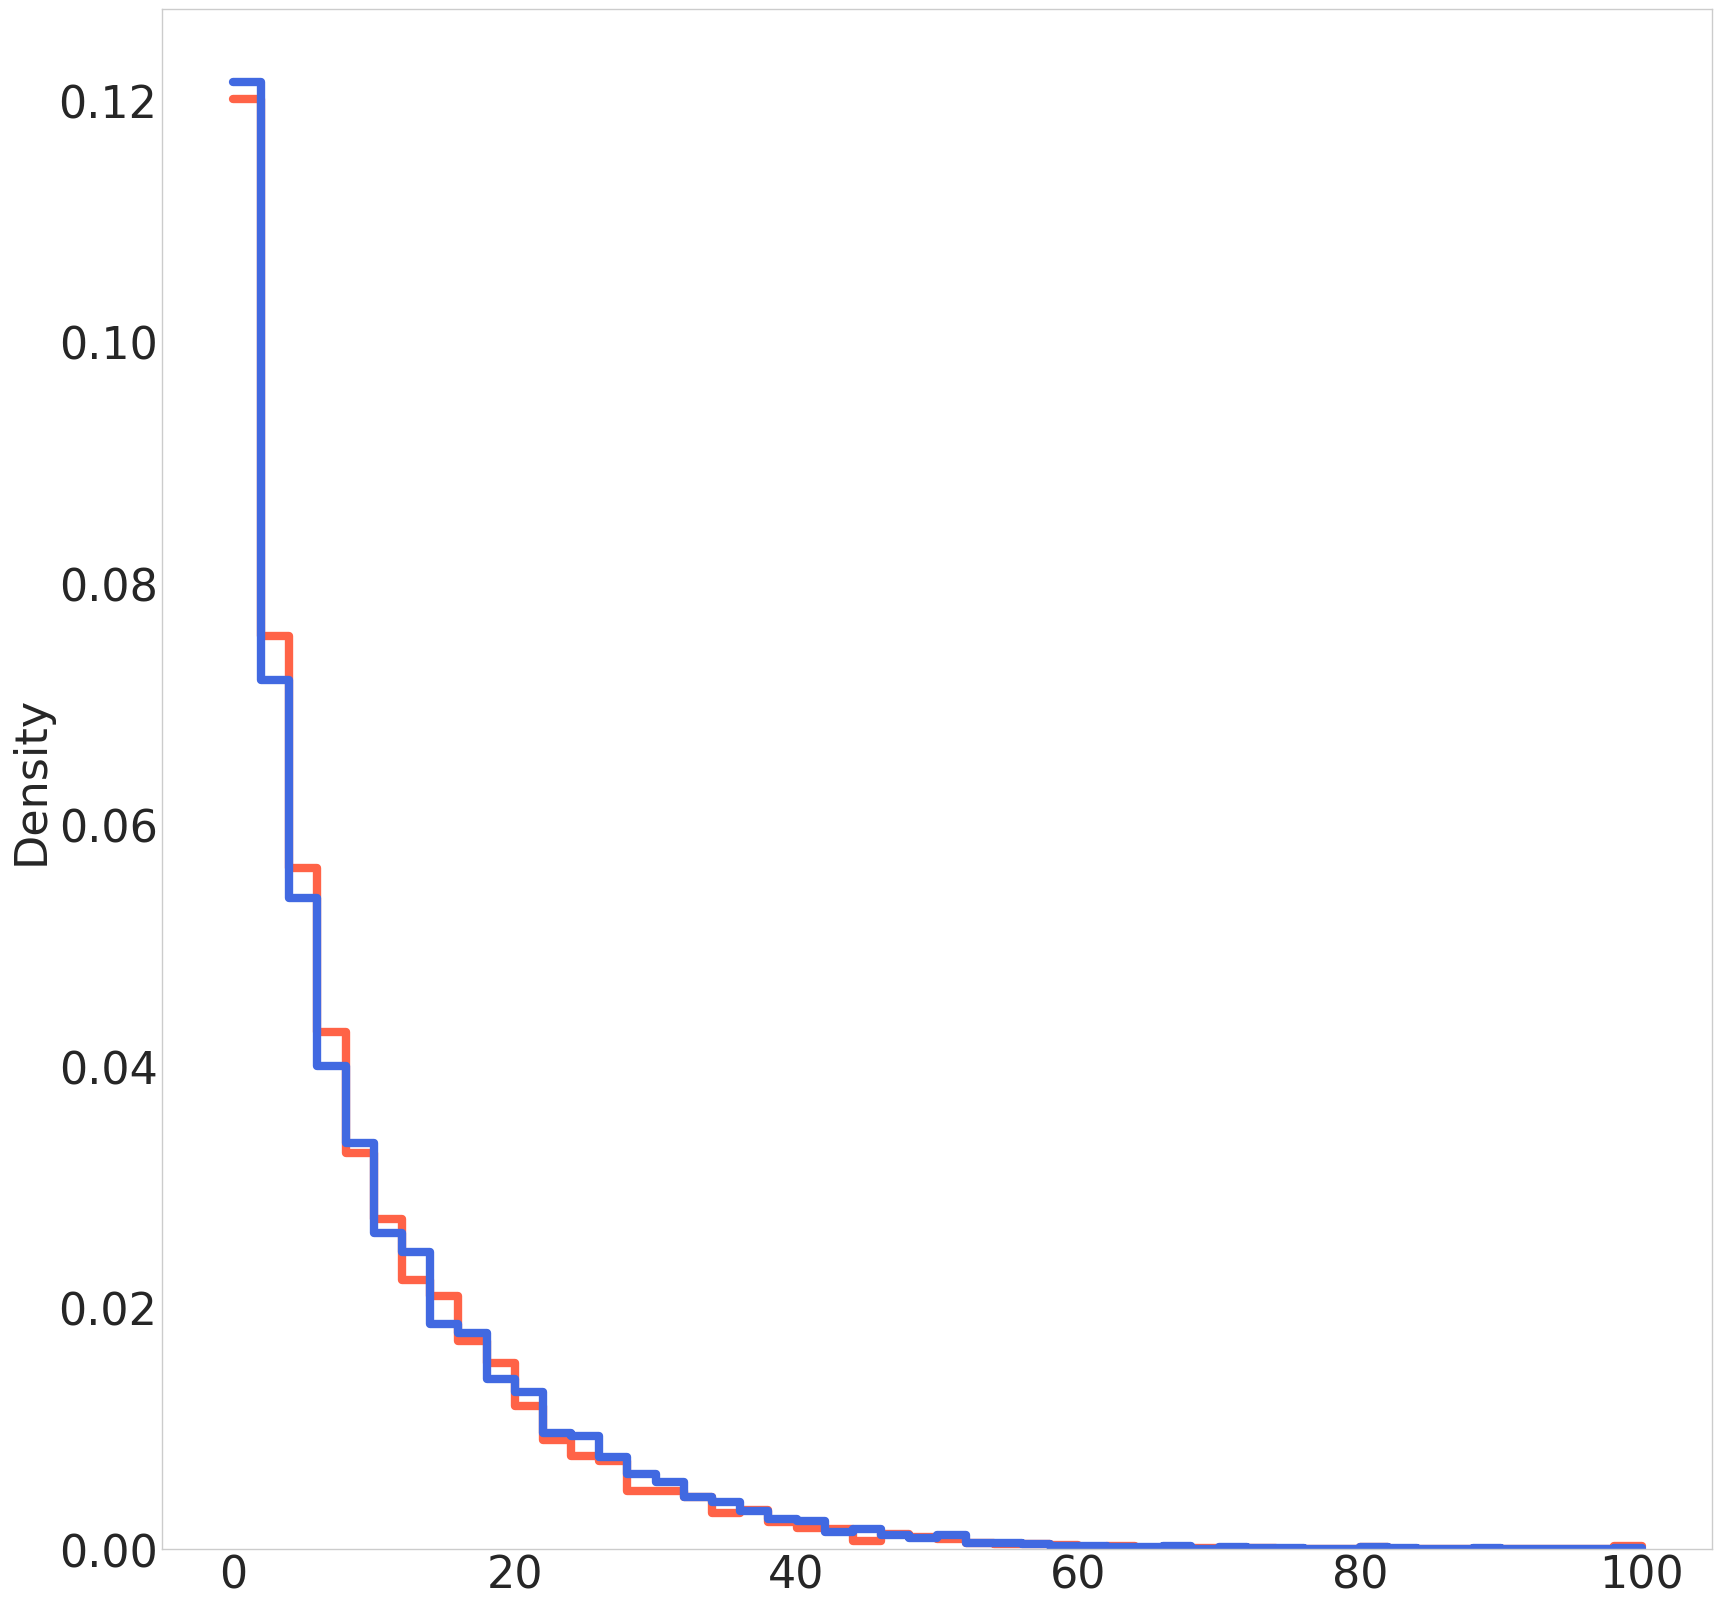

In [59]:
## Plot histogram
fig, ax = plt.subplots(figsize=(20,20))
sns.histplot(np.clip(hela_arr, 0, 100), color="tomato", label="HeLa", element="step", ax=ax, fill=False, binwidth=2, stat="density")
sns.histplot(np.clip(hek_arr,  0, 100), color="royalblue", label="HEK293T", element="step", ax=ax, fill=False, binwidth=2, stat="density")
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/density.pdf", format="pdf")
plt.show()

In [60]:
## How many genes have> 30 m6A sites?
print(len(hela_arr[hela_arr > 20])/len(hela_arr))
print(len(hek_arr[hek_arr   > 20])/len(hek_arr))

0.12603831157823359
0.1414915408542599


In [61]:
## How many genes have m6A sites?
print(len(hela_arr[hela_arr > 0])/hela_df["gene_symbol"].nunique())
print(len(hek_arr[hek_arr > 0])/hek_df["gene_symbol"].nunique())

0.8941761363636364
0.8853993179474978


In [62]:
## Average number of m6A sites per gene
print(hela_arr.mean())
print(hek_arr.mean())



9.179776233259874
9.552841210833776


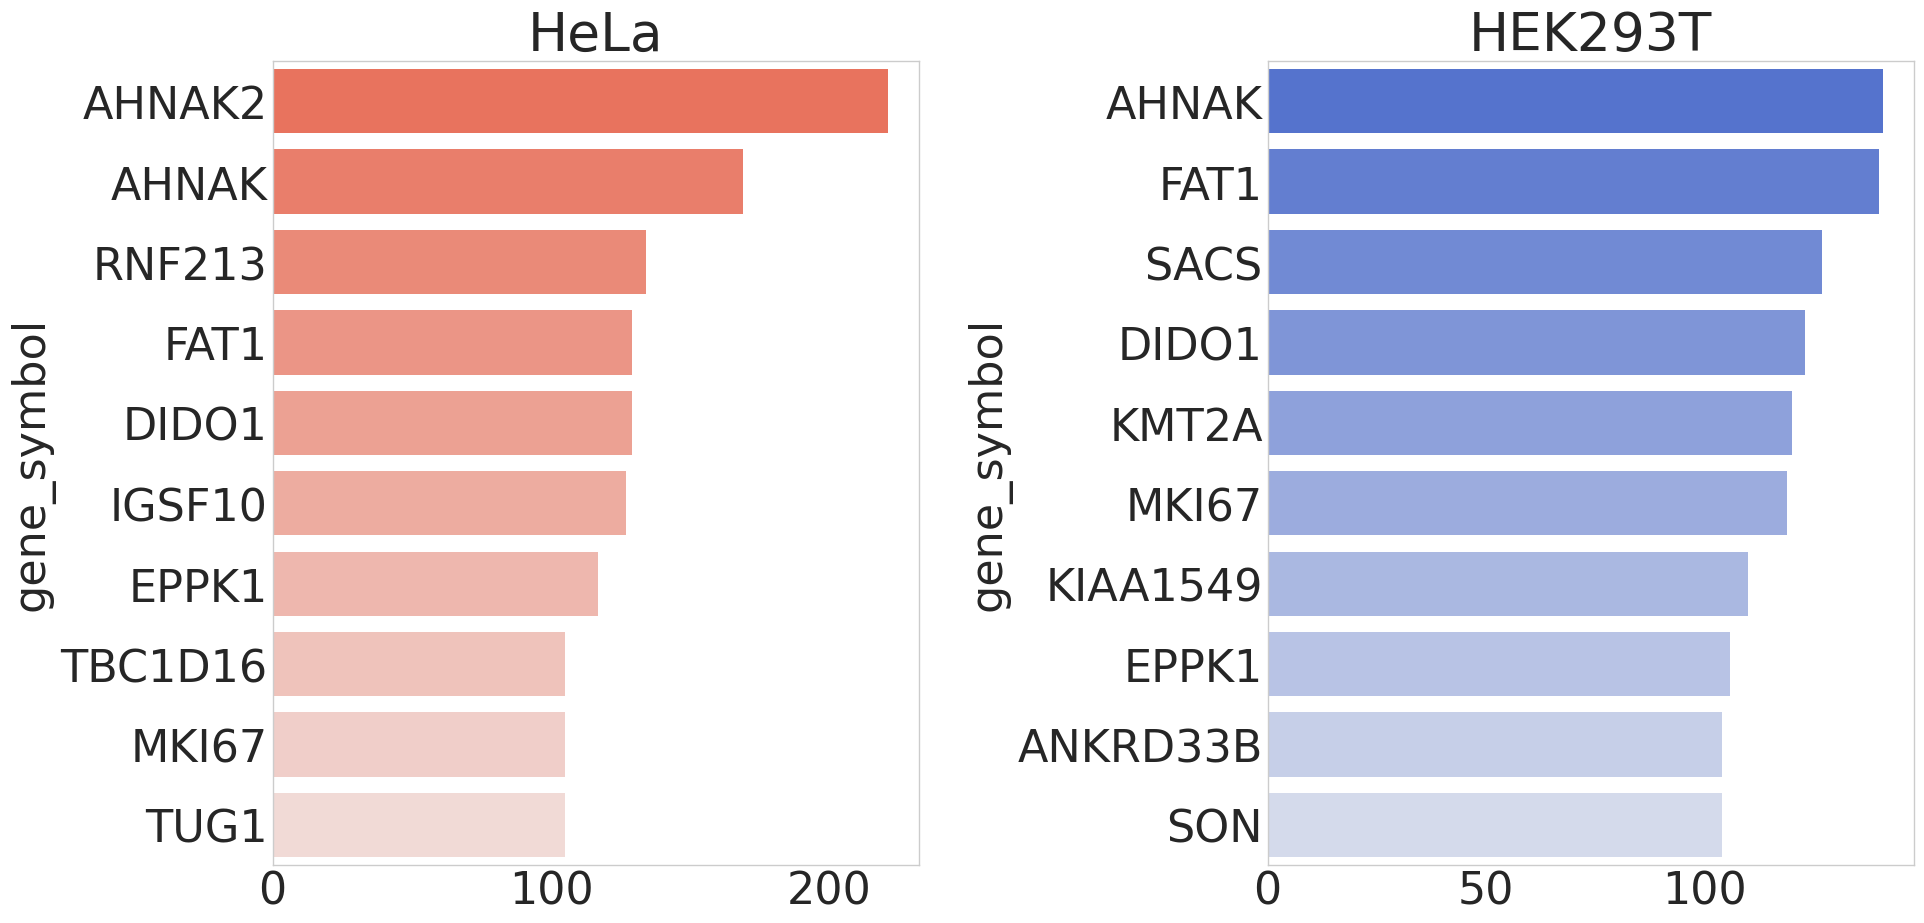

In [110]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
hela_arr = hela_arr.sort_values(ascending=False)
hek_arr = hek_arr.sort_values(ascending=False)
## Vertical bar plot
sns.barplot(x=hela_arr[:10], y=hela_arr[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_arr[:10], y=hek_arr[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [111]:
##print top10 genes

print("\n".join(hela_arr[:10].index))
print("")
print("\n".join(hek_arr[:10].index))

AHNAK2
AHNAK
RNF213
FAT1
DIDO1
IGSF10
EPPK1
TBC1D16
MKI67
TUG1

AHNAK
FAT1
SACS
DIDO1
KMT2A
MKI67
KIAA1549
EPPK1
ANKRD33B
SON


In [112]:
hela_df["pm6a"] = calc_pm6a(hela_df)
hek_df["pm6a"] = calc_pm6a(hek_df)
hela_df["refseq"] = hela_df["label_id"].str.split(":", expand=True)[0]
hek_df["refseq"] = hek_df["label_id"].str.split(":", expand=True)[0]
hela_df["pos"] = hela_df["label_id"].str.split(":", expand=True)[1].astype(int)
hek_df["pos"] = hek_df["label_id"].str.split(":", expand=True)[1].astype(int)

In [ ]:
## Get genes for largest discrepancy

gene_dict = []
for refseq in hela_dict.index:
    if refseq in hek_dict:
        hela_pos = hela_dict[refseq]
        hek_pos = hek_dict[refseq]
        diff = np.setdiff1d(hela_pos, hek_pos)
        if len(diff) > 0:
            gene_dict.append((refseq, len(diff)))

diff_df = pd.DataFrame(gene_dict, columns=["refseq", "diff"])

In [ ]:
print(diff_df)

In [ ]:
print(diff_df.sort_values("diff", ascending=False))

In [114]:
print(hela_df[hela_df["refseq"] == "NM_022489"])

                label_id      p_sum  logsum_1_p_pos       dom  count_all  \
20699411    NM_022489:10   4.180888        0.000000  0.040816         51   
20699412  NM_022489:1017  19.446039        0.000000  0.029304        290   
20699413  NM_022489:1029   8.786906       -2.071652  0.014337        290   
20699414  NM_022489:1035   3.258542       -2.332375  0.003484        290   
20699415  NM_022489:1040  12.030365        0.000000  0.014815        282   
...                  ...        ...             ...       ...        ...   
20700709   NM_022489:969  49.773682       -2.314448  0.092920        283   
20700710   NM_022489:971  19.591351        0.000000  0.047794        285   
20700711   NM_022489:972   6.327932        0.000000  0.013986        289   
20700712   NM_022489:977  15.547835       -6.820905  0.040146        285   
20700713   NM_022489:999  13.886819        0.000000  0.028777        288   

          count_dom  count_pos      pm6a     refseq   pos gene_symbol  
20699411       

In [115]:
fdr_threshold = 0.35

hela_m6a_df = hela_df[hela_df["pm6a"] > fdr_threshold]
hek_m6a_df = hek_df[hek_df["pm6a"] > fdr_threshold]

hela_count_df = pd.DataFrame(hela_m6a_df["refseq"].value_counts())
hek_count_df = pd.DataFrame(hek_m6a_df["refseq"].value_counts())

hela_count_df["a_count"] = hela_count_df.index.map(a_count_dict)
hek_count_df["a_count"] = hek_count_df.index.map(a_count_dict)

hela_count_df["density"] = hela_count_df["count"]/hela_count_df["a_count"]
hek_count_df["density"] = hek_count_df["count"]/hek_count_df["a_count"]

hela_count_df["gene_id"] = hela_count_df.index.map(convert_dict)
hek_count_df["gene_id"] = hek_count_df.index.map(convert_dict)

print(hela_count_df)
print(hek_count_df)

              count  a_count   density gene_id
refseq                                        
NM_138420       187     4423  0.042279  AHNAK2
NM_001350929    177     4406  0.040172  AHNAK2
NM_001346446    150     5446  0.027543   AHNAK
NM_001620       147     5444  0.027002   AHNAK
NM_005245       129     4184  0.030832    FAT1
...             ...      ...       ...     ...
NM_000367         1      958  0.001044    TPMT
NM_000224         1      351  0.002849   KRT18
NM_000281         1      189  0.005291   PCBD1
NM_000282         1      727  0.001376    PCCA
NM_000154         1      236  0.004237   GALK1

[20533 rows x 4 columns]
              count  a_count   density gene_id
refseq                                        
NM_005245       139     4184  0.033222    FAT1
NM_002417       127     4175  0.030419   MKI67
NM_001620       114     5444  0.020940   AHNAK
NM_001291411    109     2136  0.051030     SON
NM_031308       106     2710  0.039114   EPPK1
...             ...      ...      

In [117]:
## groupby gene_id, get max density, sort by density
hela_density_df = hela_count_df.groupby("gene_id").agg({"density": "max"}).sort_values("density", ascending=False)
hek_density_df = hek_count_df.groupby("gene_id").agg({"density": "max"}).sort_values("density", ascending=False)

print(hela_density_df)
print(hek_density_df)

          density
gene_id          
EXD3     0.132716
ADAT3    0.128713
MC1R     0.101036
MFSD5    0.100000
LRFN4    0.098191
...           ...
ARFGEF3  0.000243
SLFN12L  0.000235
CDKL5    0.000233
HOOK3    0.000230
DYNC2H1  0.000226

[10243 rows x 1 columns]
          density
gene_id          
EXD3     0.138889
ADAT3    0.133663
MFSD5    0.100000
RPRML    0.098592
SDHAF1   0.098039
...           ...
PTPN14   0.000286
PHC3     0.000262
CNTNAP3  0.000248
USF3     0.000248
AAK1     0.000169

[11408 rows x 1 columns]


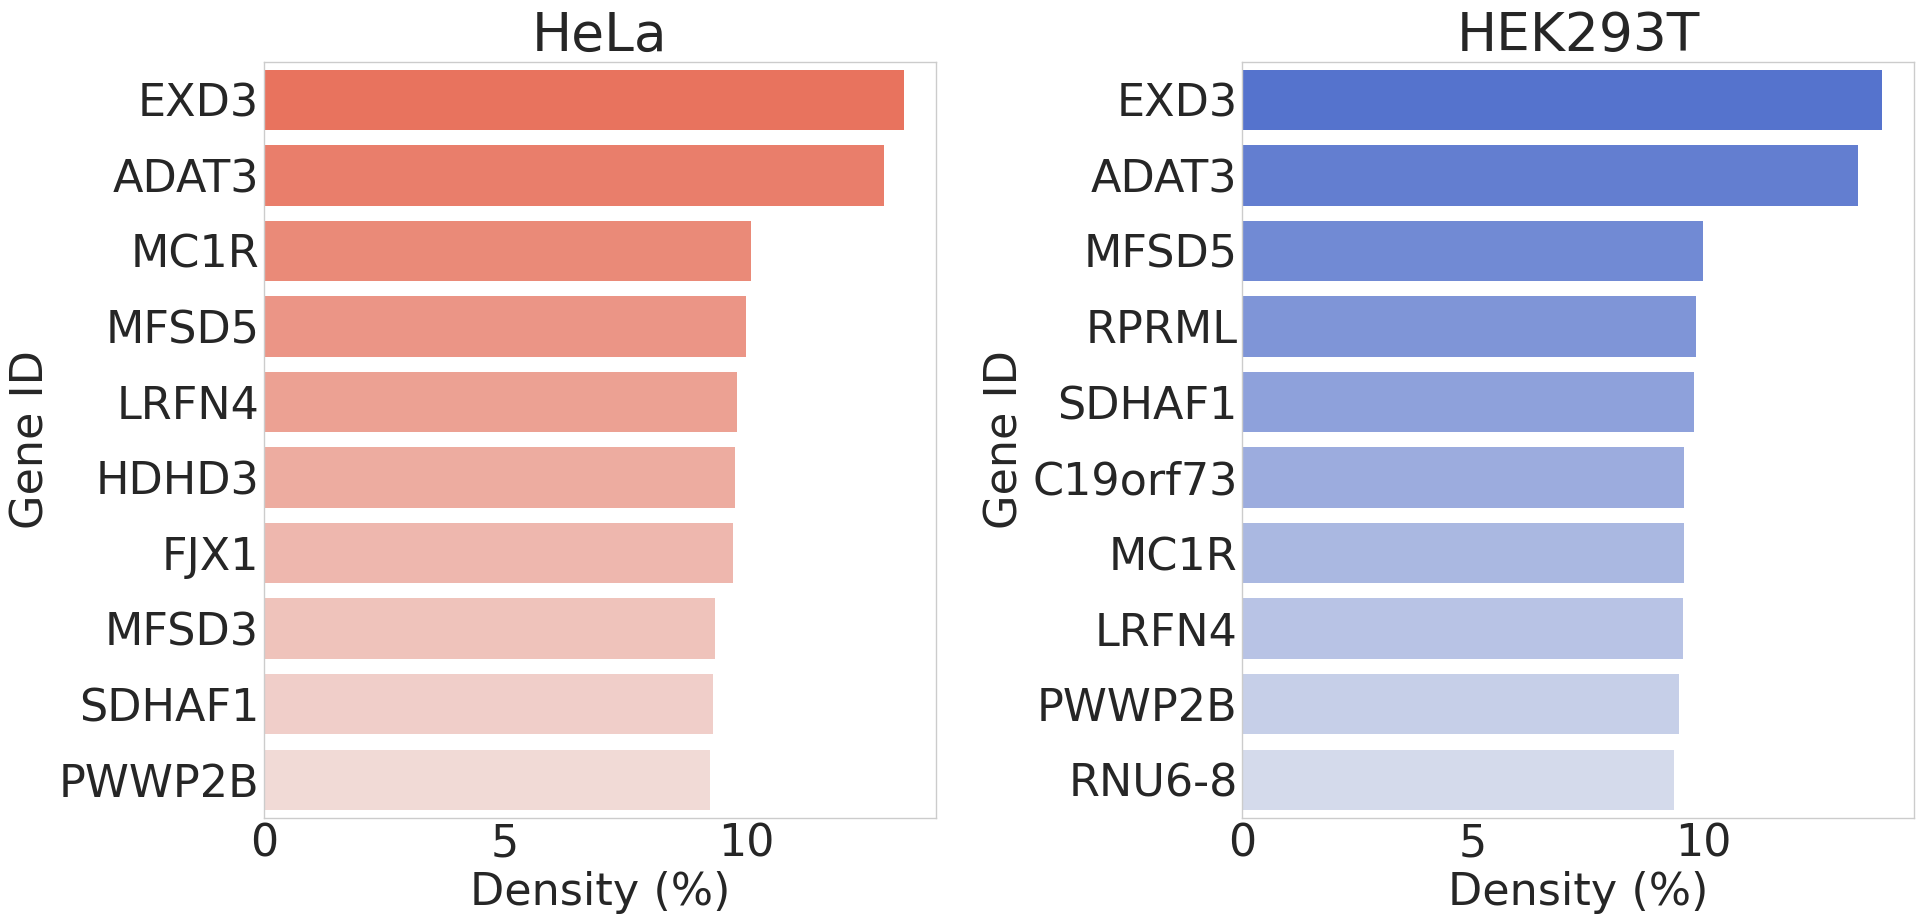

In [118]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
## Vertical bar plot
sns.barplot(x=hela_density_df[:10]["density"]*100, y=hela_density_df[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_density_df[:10]["density"]*100, y=hek_density_df[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
ax[0].set_xlabel("Density (%)")
ax[1].set_xlabel("Density (%)")
ax[0].set_ylabel("Gene ID")
ax[1].set_ylabel("Gene ID")
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [64]:
hek_count_df = hek_df["refseq"].value_counts()
hela_count_df = hela_df["refseq"].value_counts()
hek_start_df = hek_df.groupby("refseq").apply(lambda x: x["pos"].min())
hela_start_df = hela_df.groupby("refseq").apply(lambda x: x["pos"].min())


In [65]:
## get m6a pos for each refseq
fdr_threshold = 0.55
hela_df_m6a = hela_df[hela_df["pm6a"] > fdr_threshold].copy()
hek_df_m6a = hek_df[hek_df["pm6a"] > fdr_threshold].copy()
hela_dict = hela_df_m6a.groupby("refseq").apply(lambda x: x["pos"].values)
hek_dict = hek_df_m6a.groupby("refseq").apply(lambda x: x["pos"].values)

In [66]:
print(len(a_count_dict))

87410


In [68]:
gene_list = []
for gene_id in tqdm.tqdm(a_count_dict):
    a_count = a_count_dict[gene_id]
    hek_count = hek_count_df.get(gene_id, 0)
    hela_count = hela_count_df.get(gene_id, 0)
    if hek_count >= a_count * 0.75 and hela_count >= a_count * 0.75:
        if np.abs(hela_count - hek_count) < 10:
            if np.abs(hek_start_df.get(gene_id, 0) - hela_start_df.get(gene_id, 0)) < 100:
                if np.abs(hek_end_df.get(gene_id, 0) - hela_end_df.get(gene_id, 0)) < 100:
                    gene_list.append(gene_id)

gene_list = [x for x in a_count_dict if x in hela_dict or x in hek_dict]
gene_len_dict = {x: len(fasta_dict[x]) for x in gene_list}

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 87410/87410 [00:01<00:00, 70063.41it/s]


In [69]:
hela_df_ca = hela_df[hela_df["pm6a"] < threshold].copy()
hek_df_ca = hek_df[hek_df["pm6a"] < threshold].copy()

print(len(hela_df_ca)/len(hela_df))
print(len(hek_df_ca)/len(hek_df))

0.9903210943294741
0.9904945792655191


In [130]:

def plot(refseq, colour="cell"):    
    
    ## colour: cell, dynamic, drach
    
    cell_colours = ["royalblue", "tomato"]
    dynamic_colours = ["#EF962C", "#7652E3"]
    drach_colours = ["#808080", "#D7432E"]
    
    
    hela_refseq_df = hela_df_m6a[hela_df_m6a["refseq"] == refseq]
    hela_pos = hela_refseq_df["pos"].values
    hela_dom = hela_refseq_df["dom"].values
    hek_refseq_df = hek_df_m6a[hek_df_m6a["refseq"] == refseq]
    hek_pos = hek_refseq_df["pos"].values
    hek_dom = hek_refseq_df["dom"].values

    hela_ca_pos = hela_df_ca_groupby.get_group(refseq)["pos"].values
    hek_ca_pos = hek_df_ca_groupby.get_group(refseq)["pos"].values
    hela_all_pos = np.concatenate([hela_pos, hela_ca_pos])
    hek_all_pos = np.concatenate([hek_pos, hek_ca_pos])

    hela_pos_bool = np.isin(hela_pos, hek_all_pos)
    hek_pos_bool = np.isin(hek_pos, hela_all_pos)
    
    hela_pos = hela_pos[hela_pos_bool]
    hek_pos = hek_pos[hek_pos_bool]
    hela_dom = hela_dom[hela_pos_bool]
    hek_dom = hek_dom[hek_pos_bool]
    
    print(refseq)
    
    max_pos = gene_len_dict[refseq]
    
    x_min = 0
    x_max = max_pos//100 * 100 + 100
    
    if x_max - x_min > 4000:
        x_grid = 400
    
    elif x_max - x_min > 2000:
        x_grid = 200
    
    else:
        x_grid = 100
    
    fig, ax = plt.subplots(figsize=(20,10))
    
    ax.set_xticks(range(x_min, x_max, x_grid))
    ax.set_xticklabels([str(x) for x in range(x_min, x_max, x_grid)])
    ax.set_xlim(x_min - 10, x_max + 10)
    ax.set_ylim(-1, 1)
    ax.set_yticks(list(np.arange(-1,1.1,0.25)))
    ax.set_yticklabels([f"{x:.2f}" for x in np.arange(-1,1.1,0.25)])
    ax.grid()
    
    barwidth = 0.01 * (x_max - x_min + 20)
    
    if colour == "cell":
        ax.bar(hek_pos, hek_dom, label="HEK293T", color=cell_colours[0], width=barwidth)
        ax.bar(hela_pos, -hela_dom, label="HeLa", color=cell_colours[1], width=barwidth)
    
    elif colour == "dynamic":
        _, hek_static_ind, hela_static_ind = np.intersect1d(hek_pos, hela_pos, return_indices=True)
        ax.bar(hek_pos[hek_static_ind], hek_dom[hela_static_ind],color=dynamic_colours[0], width=barwidth, label="static")
        ax.bar(hela_pos[hela_static_ind], -hela_dom[hela_static_ind],  color=dynamic_colours[0], width=barwidth)
        hek_dynamic_pos = np.delete(hek_pos, hek_static_ind)
        hela_dynamic_pos = np.delete(hela_pos, hela_static_ind)
        hek_dynamic_dom = np.delete(hek_dom, hek_static_ind)
        hela_dynamic_dom = np.delete(hela_dom, hela_static_ind)
        ax.bar(hek_dynamic_pos, hek_dynamic_dom, color=dynamic_colours[1], width=barwidth, label="dynamic")
        ax.bar(hela_dynamic_pos, -hela_dynamic_dom, color=dynamic_colours[1], width=barwidth)
    
    else:
        raise ValueError("Invalid colour")
    
    gene_symbol = convert_dict[refseq]

    ax.set_title(f"{gene_symbol}({refseq}) m6A Profile")
    ax.set_xlabel("Position (nt)")
    ax.set_ylabel("Degree of Modification")
    ax.legend() 
    
    ## hline at y=0
    ax.axhline(0, color="black", lw=3)
    plt.savefig(f"/extdata4/baeklab/Hyeonseo/m6A/poster/{refseq}.pdf", format="pdf")

    plt.show()


In [ ]:

plot("NM_001161546", colour="dynamic")

In [71]:
hela_df_ca_groupby = hela_df_ca.groupby("refseq")
hek_df_ca_groupby = hek_df_ca.groupby("refseq")
hela_df_m6a_groupby = hela_df_m6a.groupby("refseq")
hek_df_m6a_groupby = hek_df_m6a.groupby("refseq")

In [72]:
print(hela_df_m6a)

                label_id      p_sum  logsum_1_p_pos       dom  count_all  \
105       NM_000016:1302  83.074715     -204.744171  0.262987        314   
794       NM_000017:1310   8.636238      -18.982704  0.163636         55   
796       NM_000017:1321  23.094213      -70.079582  0.410714         56   
808       NM_000017:1373  36.434132     -107.144432  0.700000         54   
883       NM_000017:1825  10.545633      -18.889957  0.180000         55   
...                  ...        ...             ...       ...        ...   
26475280  NR_184208:2808  41.628223     -131.709732  0.309524        132   
26475297  NR_184208:2919  29.297682      -53.971714  0.211864        132   
26475342  NR_184208:3186  32.043694      -45.582611  0.210526        130   
26478350    NR_184306:77   6.222351      -22.432709  0.214286         28   
26478381    NR_184306:93  18.177622      -54.774170  0.666667         29   

          count_dom  count_pos      pm6a     refseq   pos gene_symbol  
105            

In [73]:

gene_dict = []
for refseq in tqdm.tqdm(gene_list):
    try:
        hela_pos = hela_dict[refseq]
        hela_dom = hela_df_m6a_groupby.get_group(refseq)["dom"].values
    except KeyError:
        hela_pos = []
        hela_dom = []
    try:
        hek_pos = hek_dict[refseq]
        hek_dom = hek_df_m6a_groupby.get_group(refseq)["dom"].values
    except KeyError:
        hek_pos = []
        hek_dom = []
        
    try:
        hela_ca_pos = hela_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hela_ca_pos = []
    try:
        hek_ca_pos = hek_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hek_ca_pos = []
    
    hela_all_pos = np.concatenate([hela_pos, hela_ca_pos])
    hek_all_pos = np.concatenate([hek_pos, hek_ca_pos])
    
    

    hela_dom_dict = dict(zip(hela_pos, hela_dom))
    hek_dom_dict = dict(zip(hek_pos, hek_dom))

    unique = 0
    
    hela_valid_pos = []
    hek_valid_pos = []
    
    hela_arr = []
    hek_arr = []
    
    for pos in np.union1d(hela_pos, hek_pos):
        if pos in hela_all_pos and pos in hek_all_pos:
            if pos in hela_pos:
                hela_valid_pos.append(pos)
            if pos in hek_pos:
                hek_valid_pos.append(pos)
            hela_dom = hela_dom_dict.get(pos, 0)
            hek_dom = hek_dom_dict.get(pos, 0)
            hela_arr.append(hela_dom)
            hek_arr.append(hek_dom)
            if hela_dom*hek_dom == 0:
                unique += 1
                    
    if len(hela_arr) > 0 or len(hek_arr) > 0:
        
        hela_arr = np.array(hela_arr)
        hek_arr = np.array(hek_arr)
        hela_valid_pos = np.array(hela_valid_pos)
        hek_valid_pos = np.array(hek_valid_pos)
    
        i = np.intersect1d(hela_valid_pos, hek_valid_pos)
        u = np.union1d(hela_valid_pos, hek_valid_pos)
        
        cosine_sim = np.dot(hela_arr, hek_arr)/(np.linalg.norm(hela_arr)*np.linalg.norm(hek_arr))
        if np.isnan(cosine_sim):
            cosine_sim = 0
        cross_entropy = -np.sum(hela_arr*np.log(hek_arr+1e-30) + (1-hela_arr)*np.log(1-hek_arr+1e-30))/len(hela_arr)
        iou = len(i)/len(u)
        
        hela_size = len(hela_valid_pos)
        hek_size = len(hek_valid_pos)
        
        l1 = np.mean(np.abs(hela_arr-hek_arr))
        l2 = np.mean((hela_arr-hek_arr)**2) ** 0.5
        
        gene_dict.append((refseq, cosine_sim, cross_entropy, hela_size, hek_size, iou, unique, l1, l2))

diff_df = pd.DataFrame(gene_dict, columns=["refseq", "cosine_sim", "cross_entropy", "hela_size", "hek_size", "iou", "unique", "l1", "l2"])

print(diff_df)

  0%|                                                                                                                                                          | 1/24736 [00:07<52:33:01,  7.65s/it]/tmp/ipykernel_9123/971843873.py:64: RuntimeWarning: invalid value encountered in scalar divide
  cosine_sim = np.dot(hela_arr, hek_arr)/(np.linalg.norm(hela_arr)*np.linalg.norm(hek_arr))
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24736/24736 [00:40<00:00, 608.53it/s]


          refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
0      NM_000016    1.000000       0.580291          1         1  1.000000   
1      NM_000017    0.949439       3.497074          5         4  0.500000   
2      NM_000021    0.982296       3.111336         22        17  0.695652   
3      NM_000027    1.000000       0.601162          1         1  1.000000   
4      NM_000028    1.000000       0.609066          1         1  1.000000   
...          ...         ...            ...        ...       ...       ...   
16768  NR_183625    0.989705       1.986347          5         4  0.800000   
16769  NR_183758    0.985076       0.569233          2         2  1.000000   
16770  NR_183824    0.970859       0.412688          7        11  0.636364   
16771  NR_184202    0.852061       0.551725          3         5  0.600000   
16772  NR_184306    0.986567       0.429693          2         3  0.666667   

       unique        l1        l2  
0           0  0.038652  0.

In [74]:
print(diff_df)

          refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
0      NM_000016    1.000000       0.580291          1         1  1.000000   
1      NM_000017    0.949439       3.497074          5         4  0.500000   
2      NM_000021    0.982296       3.111336         22        17  0.695652   
3      NM_000027    1.000000       0.601162          1         1  1.000000   
4      NM_000028    1.000000       0.609066          1         1  1.000000   
...          ...         ...            ...        ...       ...       ...   
16768  NR_183625    0.989705       1.986347          5         4  0.800000   
16769  NR_183758    0.985076       0.569233          2         2  1.000000   
16770  NR_183824    0.970859       0.412688          7        11  0.636364   
16771  NR_184202    0.852061       0.551725          3         5  0.600000   
16772  NR_184306    0.986567       0.429693          2         3  0.666667   

       unique        l1        l2  
0           0  0.038652  0.

In [75]:
diff_df = diff_df.sort_values("l2", ascending=False)
select_df = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 3) & (diff_df["l2"] > 0.4) & (diff_df["refseq"].str.startswith("NM"))]
print(select_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
3832   NM_001282334    0.000000      40.464515          6         0  0.000000   
3374   NM_001258328    0.000000      36.389068          4         0  0.000000   
3341   NM_001257330    0.265323       1.142768          1         3  0.333333   
2225   NM_001161546    0.478922       0.920953          2        19  0.105263   
5213   NM_001321232    0.000000      34.764441          6         0  0.000000   
14454     NM_152421    0.000000       0.805262          0         3  0.000000   
3820   NM_001282285    0.106465      23.792699          3         1  0.333333   
7188   NM_001388394    0.737681      21.312961          3         2  0.666667   
6359   NM_001365004    0.579724      29.527427          3         1  0.333333   
10247     NM_012292    0.352822      30.358517          8         1  0.125000   
6823   NM_001376057    0.163809      24.385003          3         1  0.333333   
10306     NM_012446    0.525

In [76]:
weak_mod = diff_df[diff_df[["hela_size","hek_size"]].max(axis=1) < 5]
moderate_mod = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 5)&(diff_df[["hela_size","hek_size"]].max(axis=1) <= 20)]
strong_mod = diff_df[diff_df[["hela_size","hek_size"]].max(axis=1) > 20]
print(np.sum(weak_mod["unique"] > 0) , len(weak_mod))
print(np.sum(moderate_mod["unique"] > 0) , len(moderate_mod))
print(np.sum(strong_mod["unique"] > 0) , len(strong_mod))

4385 7781
6562 7442
1533 1550


In [77]:
for i in range(len(select_df)):
    plot(select_df.iloc[i]["refseq"])

NameError: name 'plot' is not defined

In [78]:
diff_df["nonunique"] = (diff_df["hela_size"]+diff_df["hek_size"]-diff_df["unique"])//2
print(diff_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size  iou  \
14265     NM_145080         0.0      58.914757          1         0  0.0   
16167     NR_104049         0.0      55.262042          1         0  0.0   
16162     NR_104015         0.0      54.612595          2         0  0.0   
7168   NM_001387999         0.0       1.540445          0         1  0.0   
8412      NM_003370         0.0      40.504243          2         0  0.0   
...             ...         ...            ...        ...       ...  ...   
15186     NM_198830         1.0       0.645390          1         1  1.0   
694       NM_001019         1.0       0.692509          1         1  1.0   
656    NM_001017928         1.0       0.566653          1         1  1.0   
2344   NM_001166135         1.0       0.617242          1         1  1.0   
12185     NM_019103         1.0       0.585953          1         1  1.0   

       unique            l1            l2  nonunique  
14265       1  8.528785e-01  8.5

In [83]:
weak_mod = diff_df[diff_df[["hela_size","hek_size"]].max(axis=1) < 5]
moderate_mod = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 5)&(diff_df[["hela_size","hek_size"]].max(axis=1) <= 10)]
strong_mod = diff_df[diff_df[["hela_size","hek_size"]].max(axis=1) > 10]
print(np.sum(weak_mod["unique"]) / (np.sum(weak_mod["nonunique"])+np.sum(weak_mod["unique"])))
print(np.sum(moderate_mod["unique"]) / (np.sum(moderate_mod["nonunique"])+np.sum(moderate_mod["unique"])))
print(np.sum(strong_mod["unique"]) / (np.sum(strong_mod["nonunique"]) + np.sum(strong_mod["unique"])))

0.34929718317684316
0.2610744022045098
0.216102541455054


In [95]:
print(weak_mod[(weak_mod["unique"]>2) & (weak_mod["cosine_sim"] < 0.3) & (weak_mod["cosine_sim"] > 0)])

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
2264   NM_001164095    0.200781       2.412928          2         3  0.250000   
7550   NM_001411044    0.224358      12.977060          3         3  0.200000   
7078   NM_001384981    0.273555      12.872143          3         2  0.250000   
15373     NM_206873    0.102012       4.078553          2         3  0.250000   
12086     NM_018677    0.159899       9.494636          2         3  0.250000   
11510     NM_016602    0.288551      16.471283          4         1  0.250000   
5734   NM_001346409    0.228745       6.780876          2         4  0.200000   
4935   NM_001318249    0.236573       9.860718          3         2  0.250000   
15740     NR_033149    0.097248       6.464302          4         4  0.142857   
5225   NM_001321324    0.253689       4.562370          4         3  0.166667   
13923     NM_080684    0.189062       8.381987          3         2  0.250000   
14670     NM_173348    0.295

In [ ]:
selected_refseq = weak_mod[(weak_mod["unique"]>2) & (weak_mod["cosine_sim"] < 0.3) & (weak_mod["cosine_sim"] > 0)]["refseq"]
for refseq in selected_refseq:
    plot(refseq)

In [100]:
print(strong_mod[(strong_mod["unique"]>3) & (strong_mod["cosine_sim"] < 0.7) & (strong_mod["cosine_sim"] > 0)])

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
16512     NR_145819    0.674489      13.660380         13        13  0.444444   
2225   NM_001161546    0.478922       0.920953          2        19  0.105263   
8796      NM_004289    0.607129       0.667221          4        25  0.160000   
16429     NR_135765    0.689525      11.005163         16        10  0.368421   
10886     NM_015099    0.543378      12.583673         11         2  0.181818   
15041     NM_183380    0.647368       5.156864         11        10  0.312500   
15026     NM_183006    0.695645       1.241445          6        12  0.384615   
9612      NM_006154    0.627250       6.159492         13         7  0.250000   

       unique        l1        l2  nonunique  
16512      10  0.447056  0.589365          8  
2225       17  0.507122  0.547969          2  
8796       21  0.378882  0.440927          4  
16429      12  0.321620  0.359572          7  
10886       9  0.217382  0.255972  

NR_145819


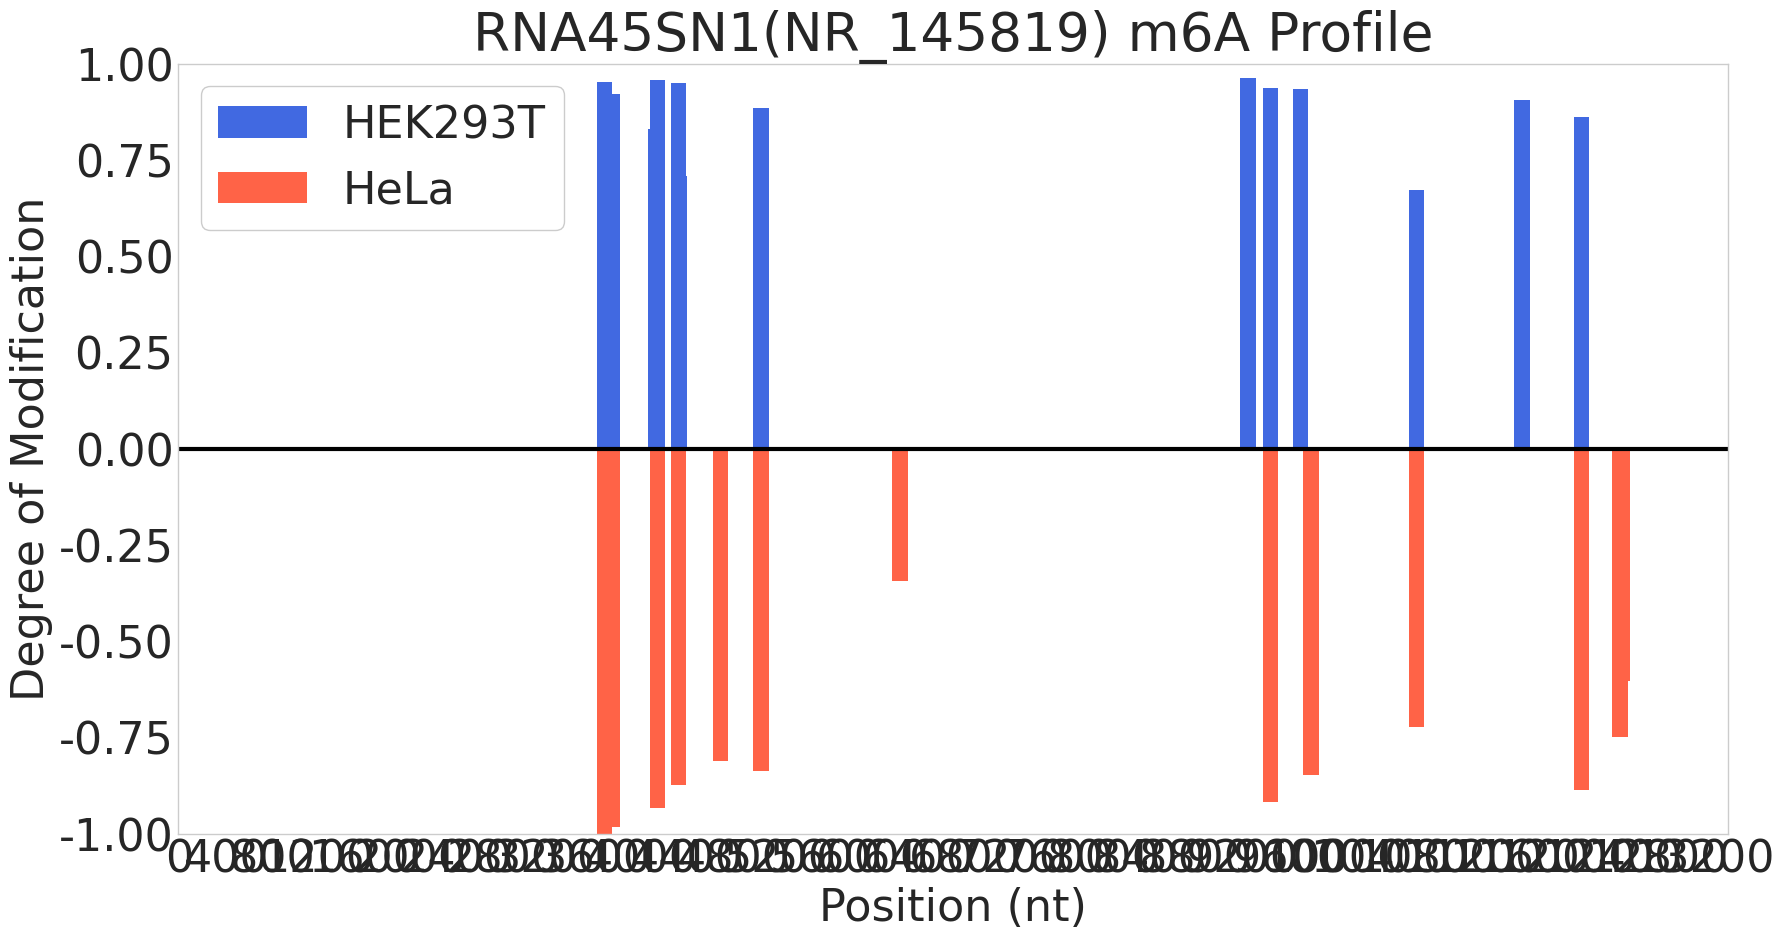

NM_001161546


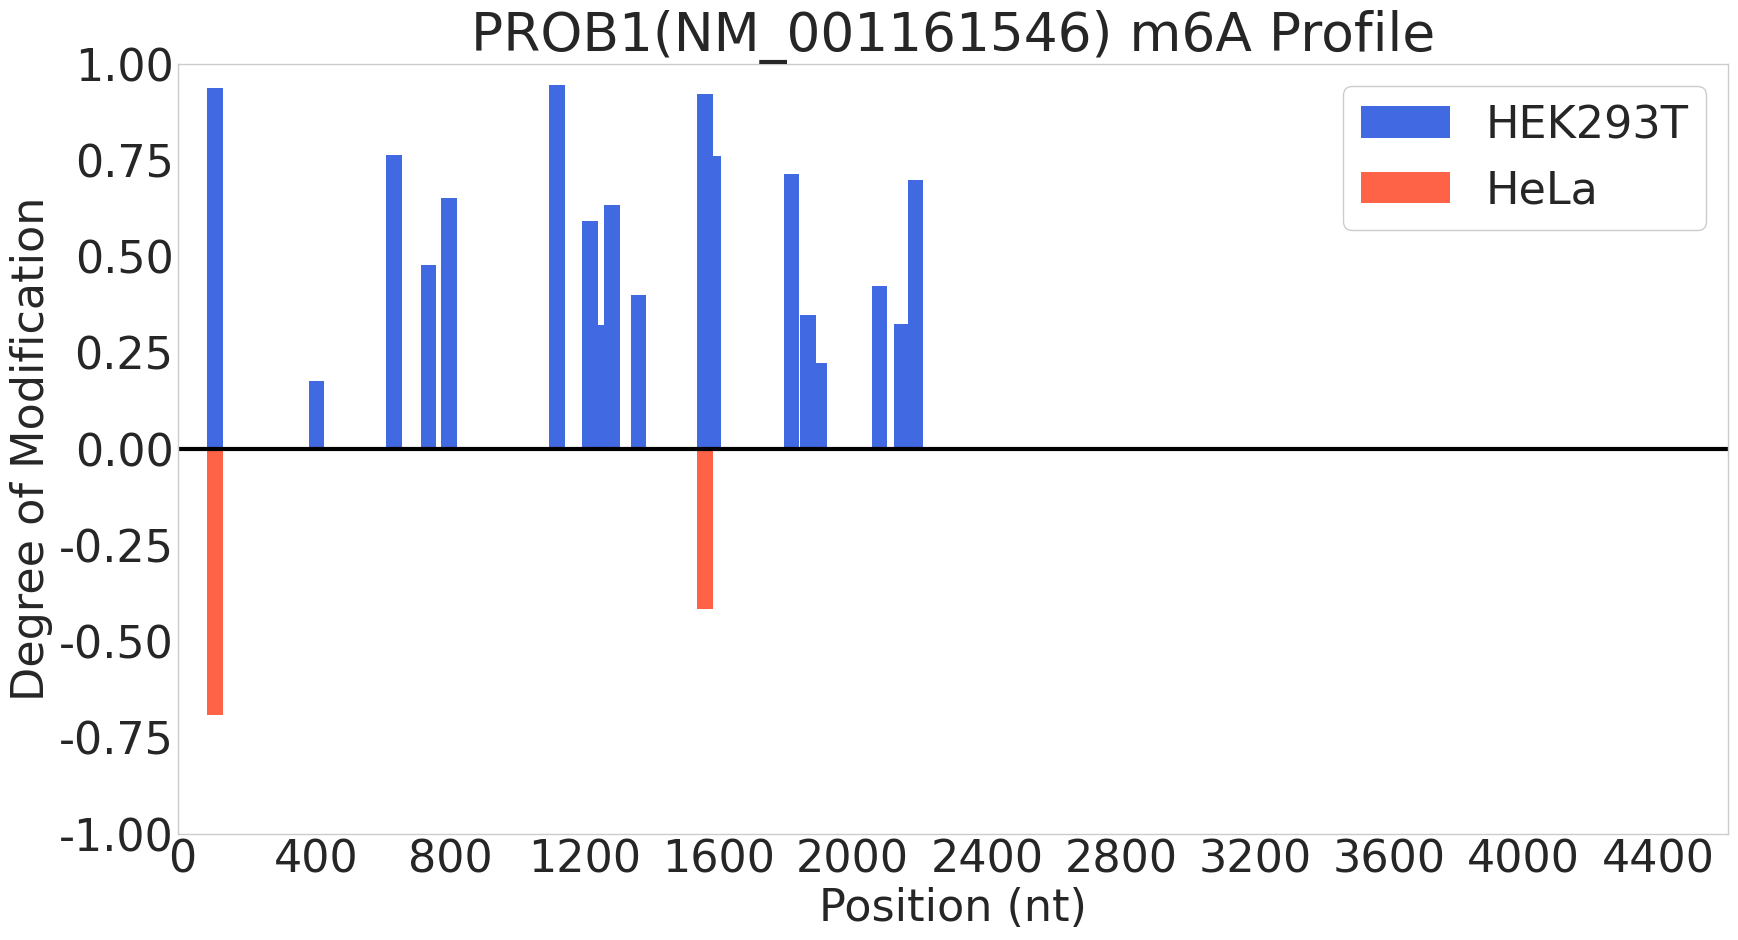

NM_004289


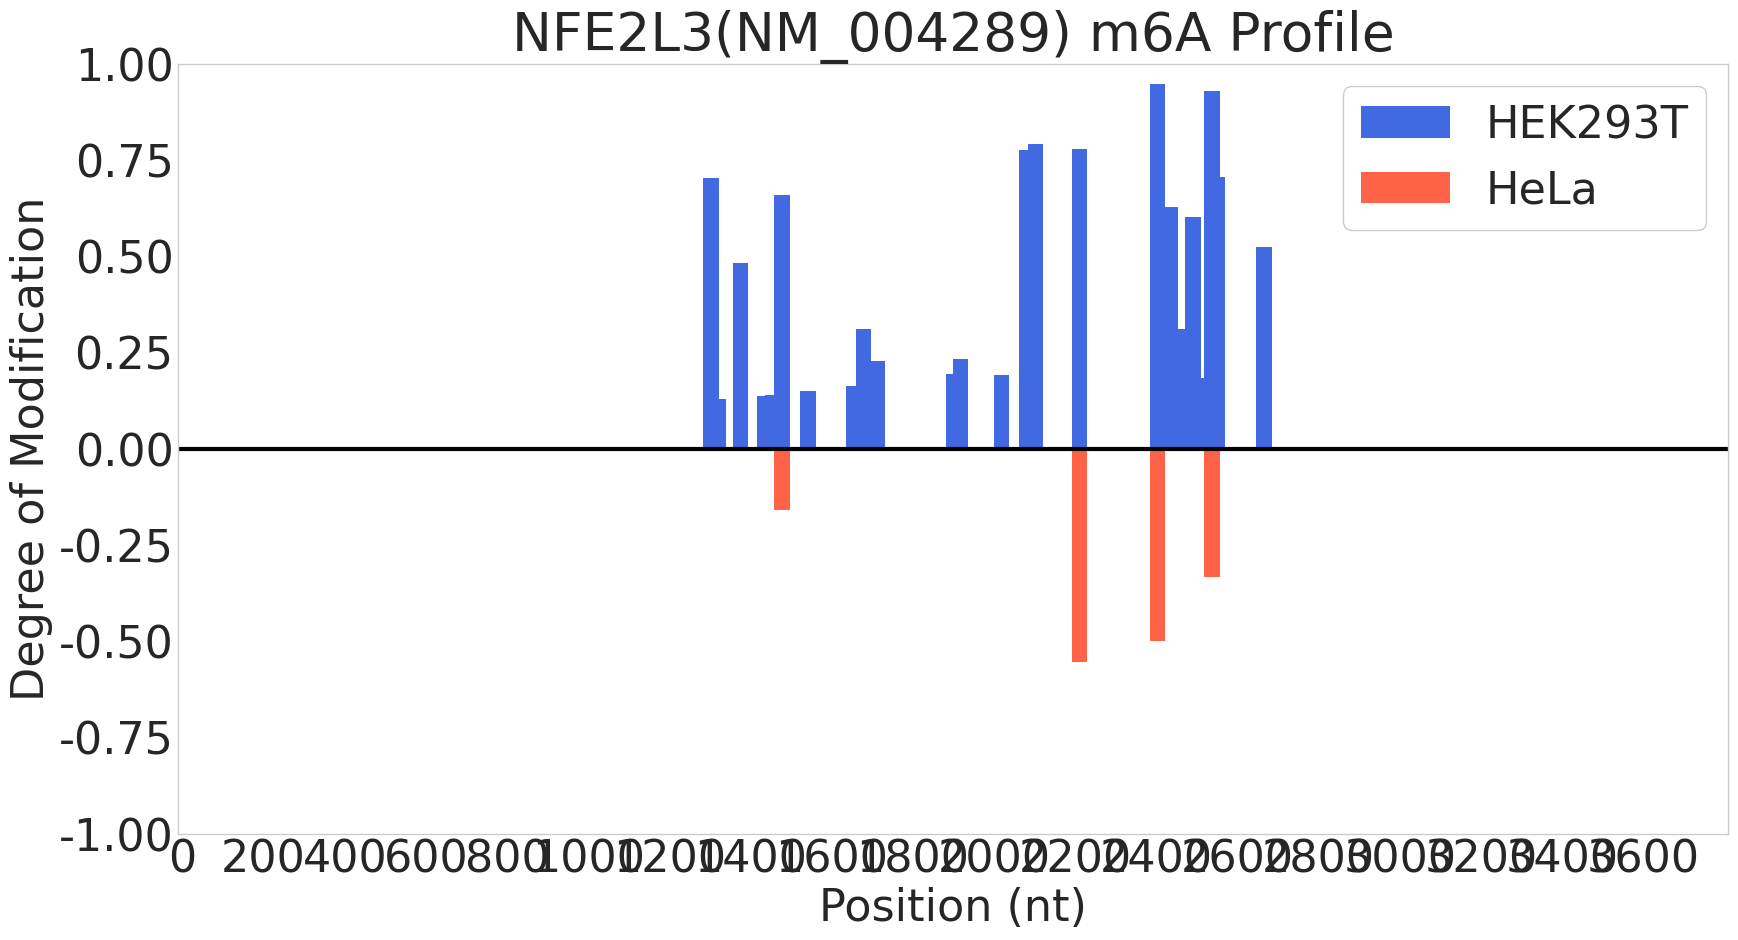

NR_135765


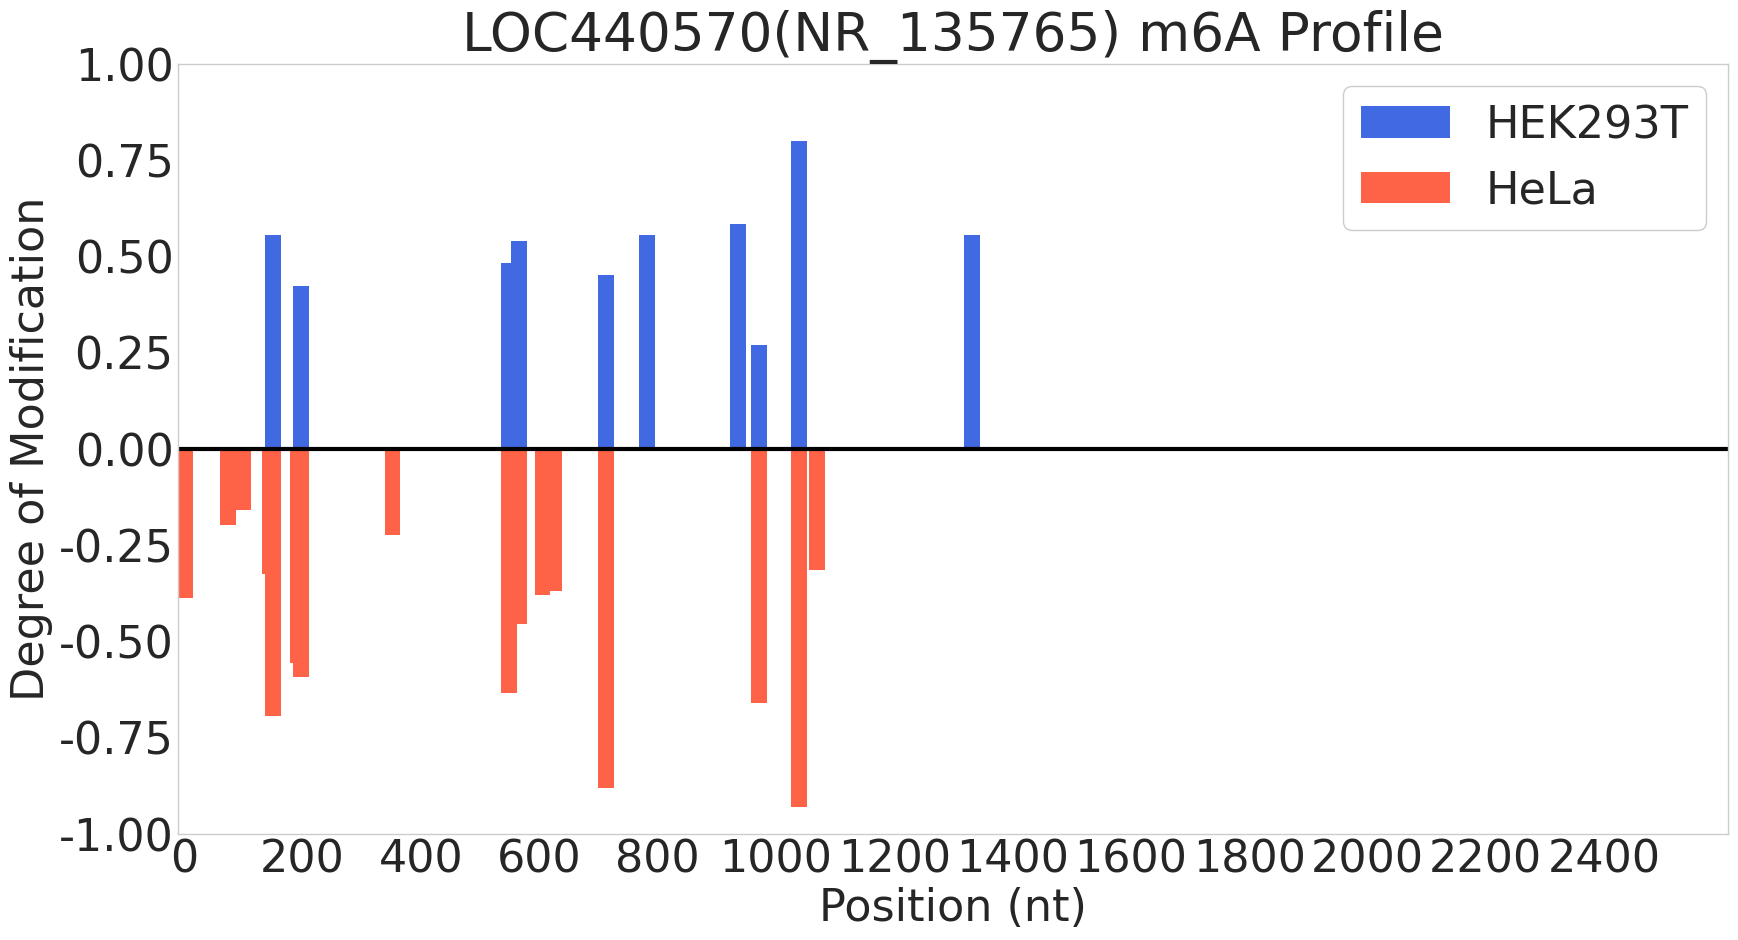

NM_015099


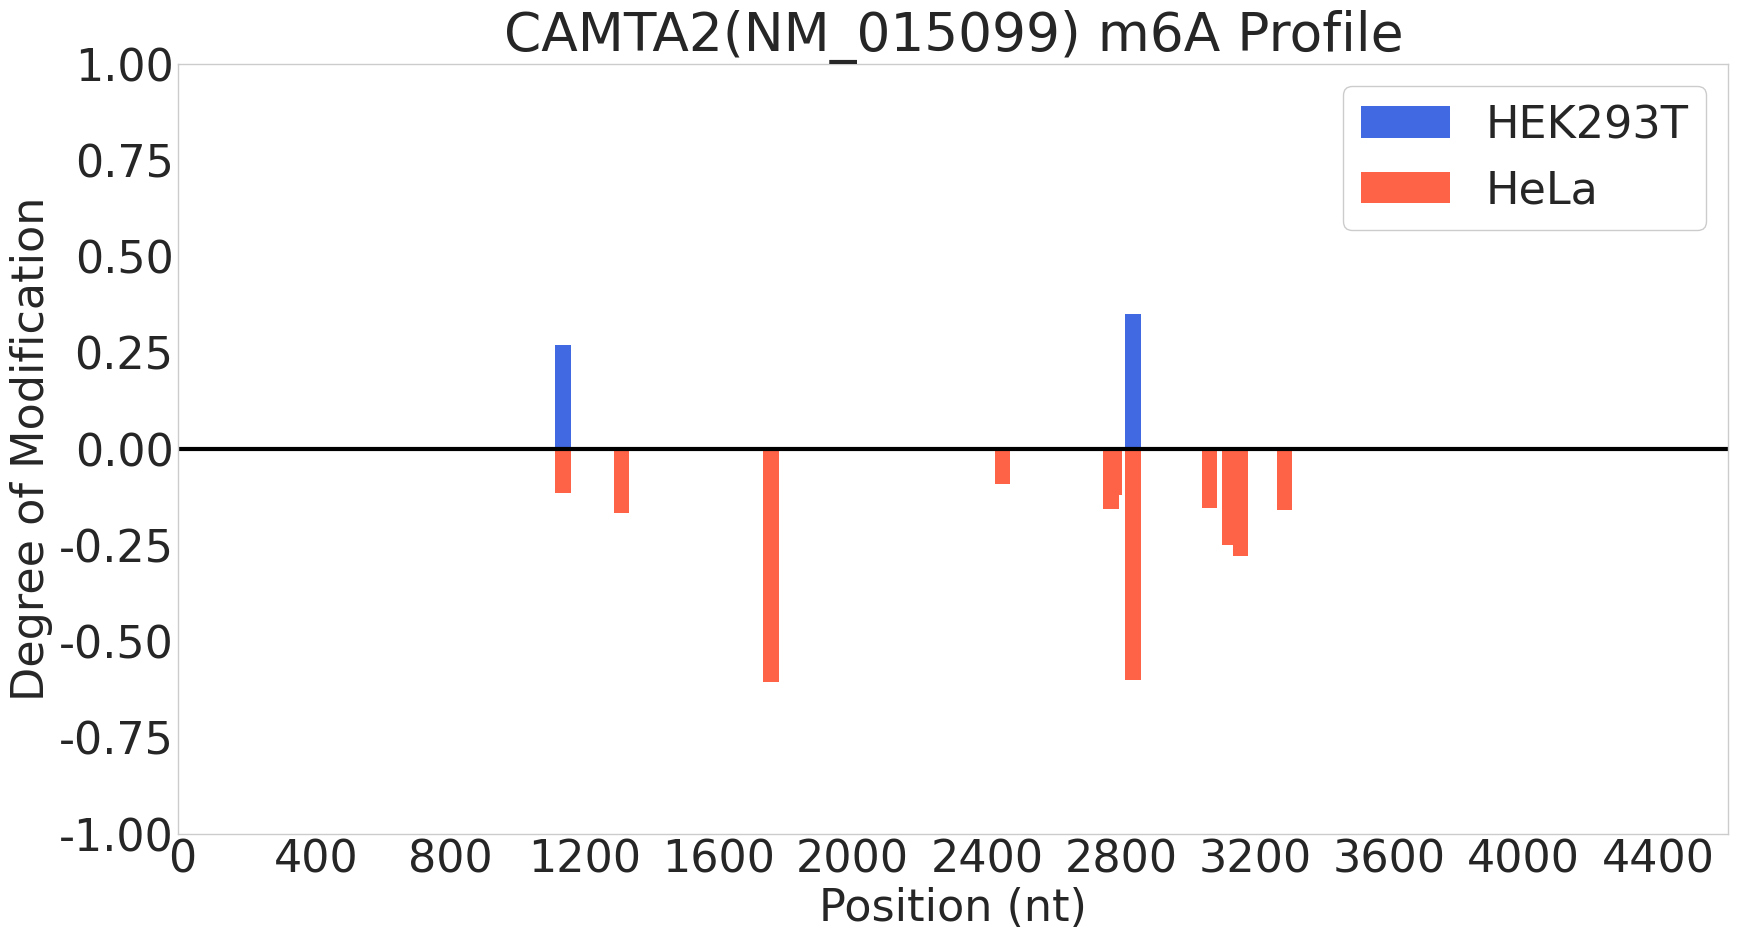

NM_183380


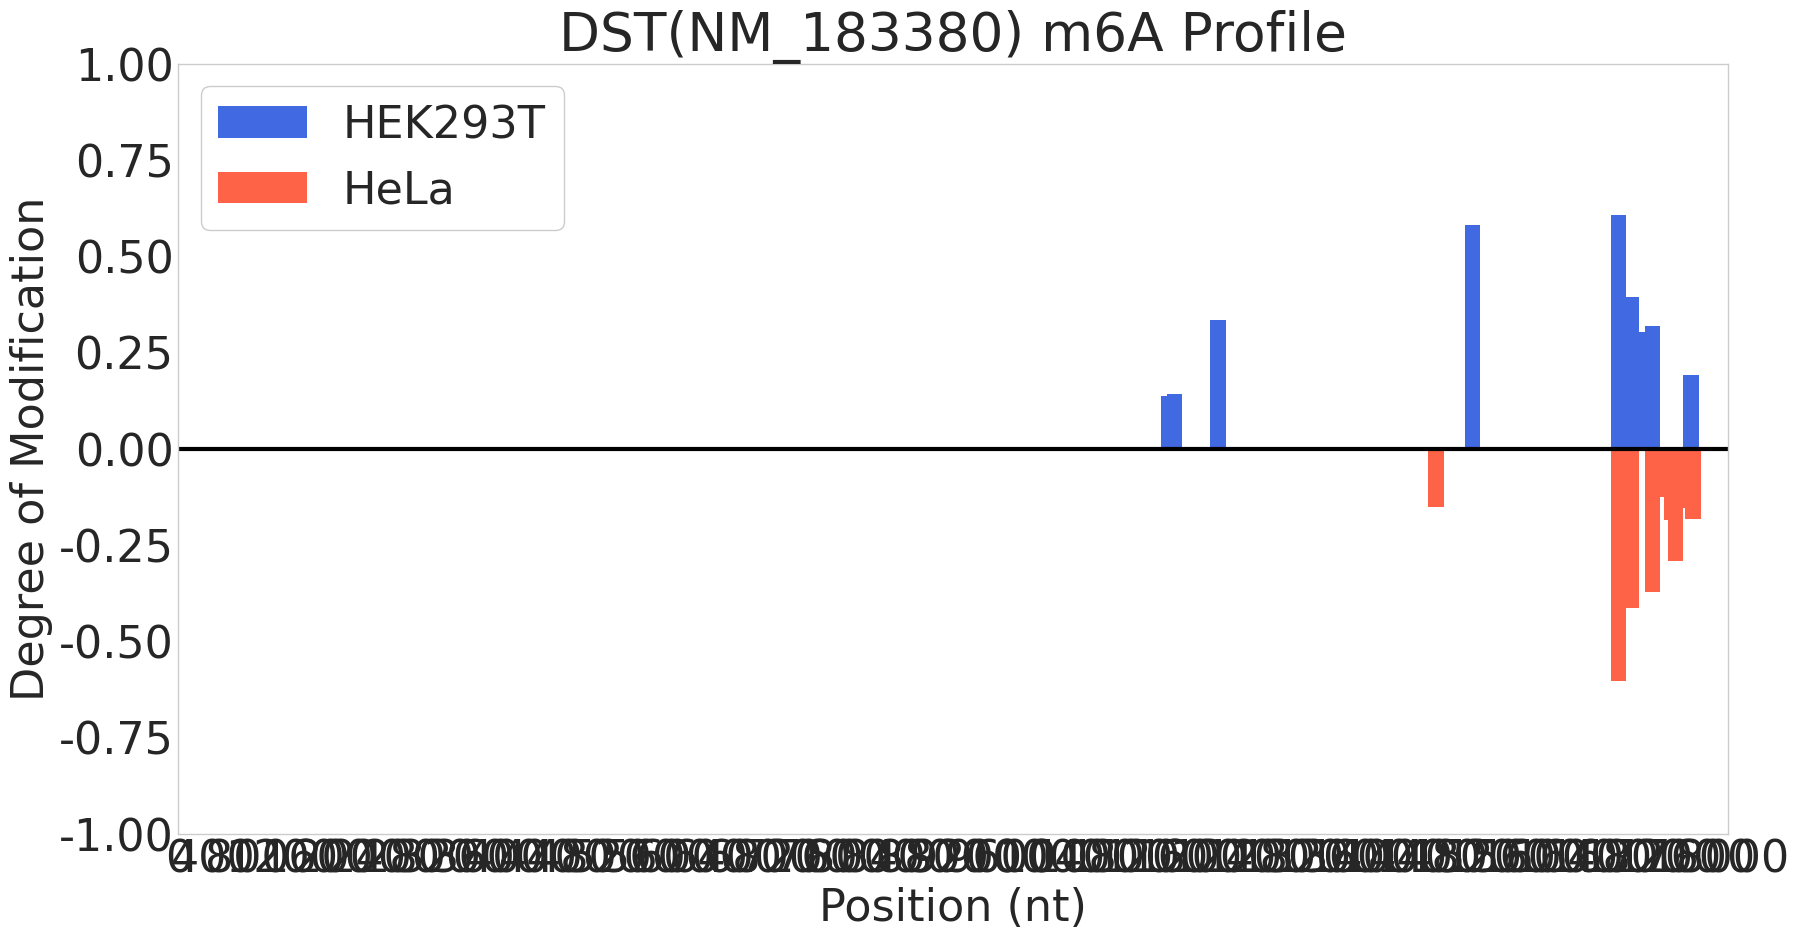

NM_183006


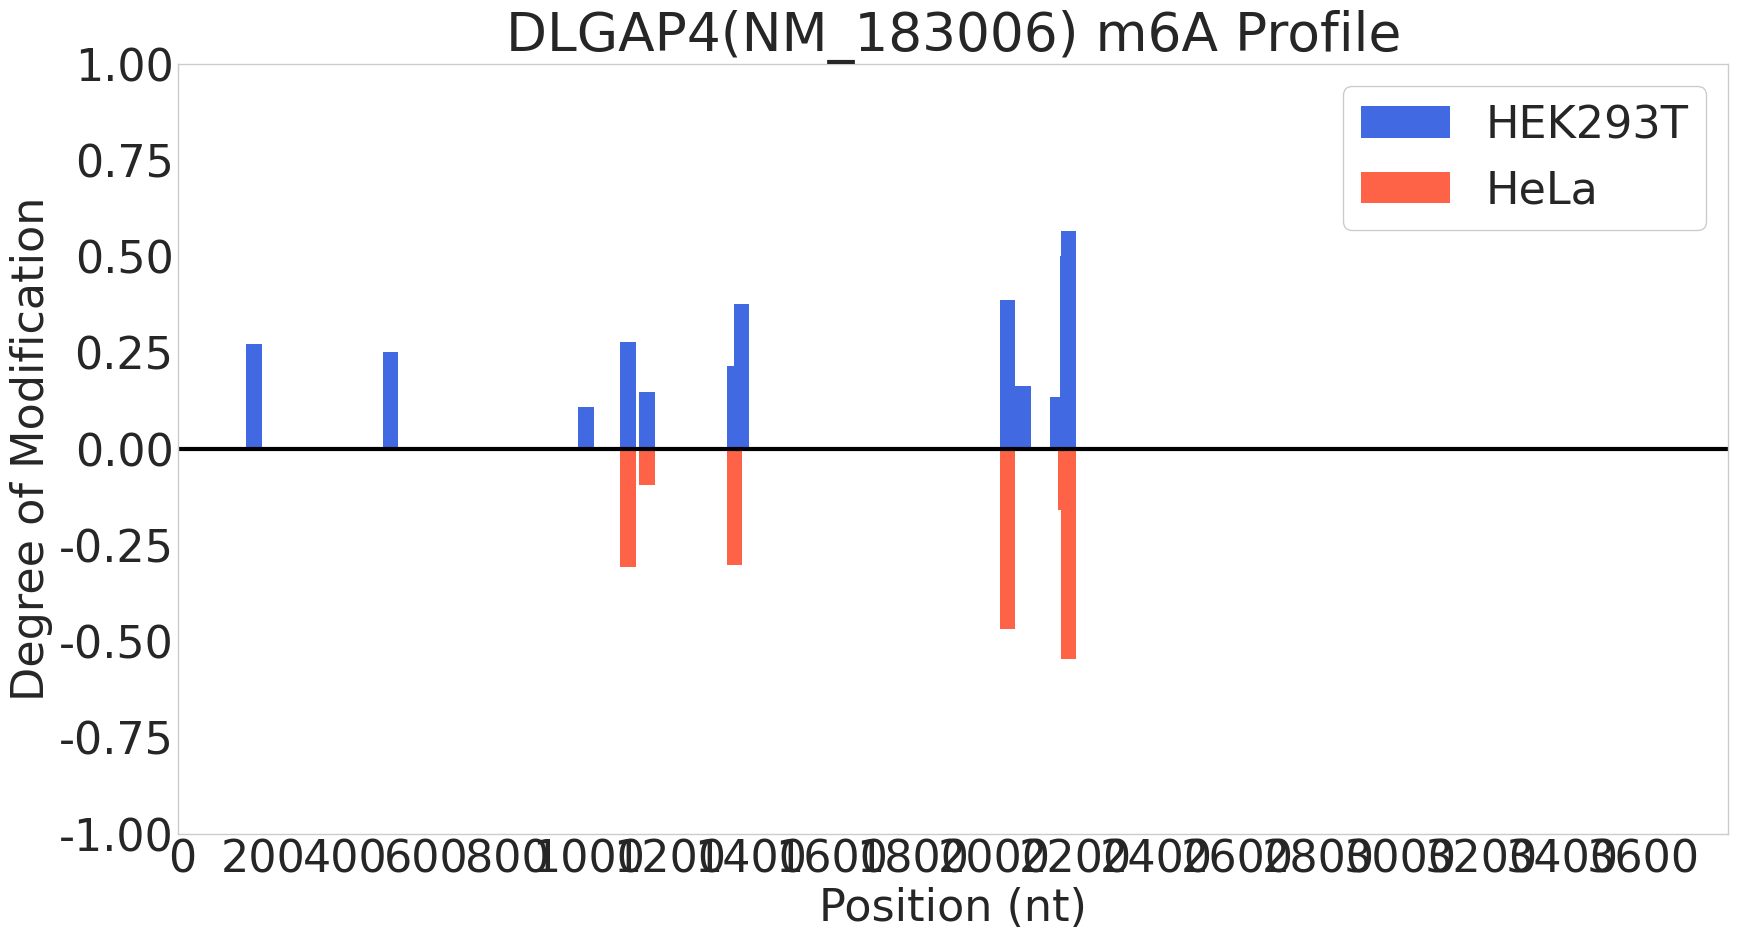

NM_006154


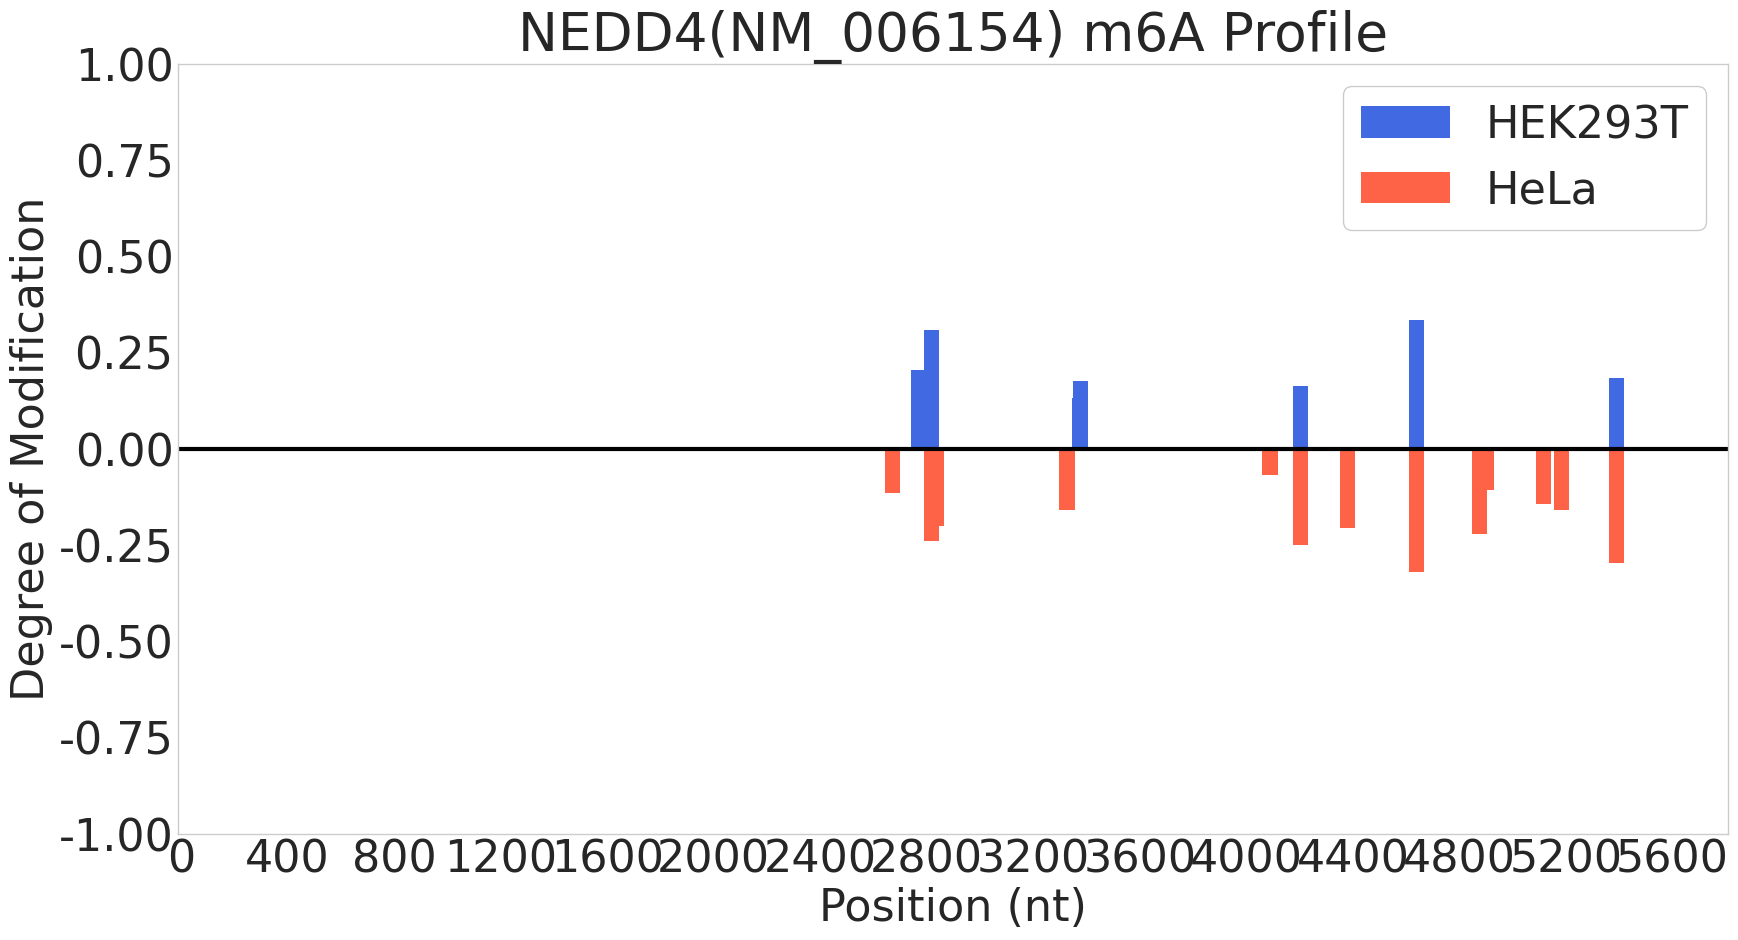

In [103]:
selected_refseq = strong_mod[(strong_mod["unique"]>3) & (strong_mod["cosine_sim"] < 0.7) & (strong_mod["cosine_sim"] > 0)]["refseq"]
for refseq in selected_refseq:
    plot(refseq)

In [ ]:
diff_df["gene_symbol"] = diff_df["refseq"].map(convert_dict)
print(diff_df)

In [ ]:
diff_df_unique = diff_df[diff_df["unique"] > 0]["gene_symbol"].unique()
print(len(diff_df_unique))

In [911]:
glori_df["seq"] = glori_df.apply(lambda x: "".join(fasta_dict[x["NMID"]][x["transcript_coordinate"]-2:x["transcript_coordinate"]+3]), axis=1)
print(glori_df)

          Chr Strand      Sites  m6A_level_rep1  m6A_level_rep2 chrstrand  \
0        chr9      +  134440485         0.69333         0.77922     chr9+   
1        chr9      +  134440485         0.69333         0.77922     chr9+   
2        chr9      +  134440485         0.69333         0.77922     chr9+   
3        chr9      -  137300014         0.78736         0.82895     chr9-   
4        chr9      -  137300274         0.62796         0.66242     chr9-   
...       ...    ...        ...             ...             ...       ...   
495172  chr17      +   48051150         0.91228         0.89783    chr17+   
495173  chr17      +   48051150         0.91228         0.89783    chr17+   
495174  chr17      +   48051197         0.34035         0.36547    chr17+   
495175  chr17      +   48051197         0.34035         0.36547    chr17+   
495176  chr17      +   48051197         0.34035         0.36547    chr17+   

                NMID  transcript_coordinate    seq  
0          NM_002957  

In [171]:
hela_temp = hela_df[["label_id","pm6a","dom","count_all"]].copy()
hela_temp.rename(columns={"pm6a": "pm6a_hela", "dom": "dom_hela", "count_all": "count_hela"}, inplace=True)
hek_temp = hek_df[["label_id","pm6a","dom","count_all"]].copy()
hek_temp.rename(columns={"pm6a": "pm6a_hek", "dom": "dom_hek", "count_all": "count_hek"}, inplace=True)
joint_df = hela_temp.merge(hek_temp, on="label_id", how="inner")

print(joint_df)


                label_id  pm6a_hela  dom_hela  count_hela  pm6a_hek   dom_hek  \
0         NM_000016:1000   0.000000  0.000000         310  0.000000  0.000000   
1         NM_000016:1008  -0.000000  0.006452         310  0.000000  0.000000   
2         NM_000016:1009  -0.000000  0.003247         311 -0.000000  0.003891   
3         NM_000016:1010  -0.000000  0.003236         313 -0.000000  0.011583   
4         NM_000016:1014  -0.000000  0.006557         312  0.000000  0.000000   
...                  ...        ...       ...         ...       ...       ...   
11904485    NR_184306:85   0.000000  0.000000          27  0.000000  0.000000   
11904486    NR_184306:87   0.000000  0.000000          29  0.092186  0.061224   
11904487    NR_184306:88   0.000000  0.000000          29 -0.000000  0.039216   
11904488    NR_184306:93   2.384901  0.666667          29  1.919874  0.695652   
11904489    NR_184306:98  -0.000000  0.160000          28  0.000000  0.000000   

          count_hek  
0    

In [172]:
joint_df["pm6a_max"] = joint_df[["pm6a_hela", "pm6a_hek"]].max(axis=1)
print(joint_df[joint_df["pm6a_max"] > threshold])

                label_id  pm6a_hela  dom_hela  count_hela  pm6a_hek   dom_hek  \
105       NM_000016:1302   1.072059  0.262987         314  0.913509  0.224335   
784       NM_000017:1321   1.873339  0.410714          56  2.021584  0.492063   
796       NM_000017:1373   2.422191  0.700000          54  2.437110  0.632000   
872       NM_000017:1829   0.529033  0.129630          55  0.756829  0.138462   
2169      NM_000021:1584   3.262655  0.920455          90  3.293502  0.992908   
...                  ...        ...       ...         ...       ...       ...   
11903849  NR_184202:2382   0.141574  0.142857          35  0.721337  0.277778   
11903917  NR_184202:2552   0.335639  0.178571          34  0.888797  0.368421   
11903992  NR_184202:2708   0.759827  0.523810          35  0.968670  0.533333   
11904484    NR_184306:77   1.382304  0.214286          28  1.229243  0.260870   
11904488    NR_184306:93   2.384901  0.666667          29  1.919874  0.695652   

          count_hek  pm6a_m

In [173]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df.reset_index(inplace=True)
print(label_df)

             index        label_id  depth  label  dom_label   5mer  drach
0                0    NM_000084:34      7      0        0.0  GCAGA  False
1                1    NM_000084:36      7      0        0.0  AGAGA  False
2                2    NM_000084:38      7      0        0.0  AGAAT  False
3                3    NM_000084:39      7      0        0.0  GAATG  False
4                4    NM_000084:43      7      0        0.0  GCAGC  False
...            ...             ...    ...    ...        ...    ...    ...
30960573  30960573  NR_183446:1338     51     -3        0.0  AGAAG  False
30960574  30960574  NR_183446:1339     51     -3        0.0  GAAGC  False
30960575  30960575  NR_183446:1347     51     -3        0.0  TCATT  False
30960576  30960576  NR_183446:1350     51     -3        0.0  TTAGC  False
30960577  30960577  NR_183446:1353     51     -3        0.0  GCAGG  False

[30960578 rows x 7 columns]


In [174]:
joint_df = joint_df.merge(label_df, on="label_id", how="inner")

In [175]:
print(joint_df)

                label_id  pm6a_hela  dom_hela  count_hela  pm6a_hek   dom_hek  \
0         NM_000016:1000   0.000000  0.000000         310  0.000000  0.000000   
1         NM_000016:1008  -0.000000  0.006452         310  0.000000  0.000000   
2         NM_000016:1009  -0.000000  0.003247         311 -0.000000  0.003891   
3         NM_000016:1010  -0.000000  0.003236         313 -0.000000  0.011583   
4         NM_000016:1014  -0.000000  0.006557         312  0.000000  0.000000   
...                  ...        ...       ...         ...       ...       ...   
11904485    NR_184306:85   0.000000  0.000000          27  0.000000  0.000000   
11904486    NR_184306:87   0.000000  0.000000          29  0.092186  0.061224   
11904487    NR_184306:88   0.000000  0.000000          29 -0.000000  0.039216   
11904488    NR_184306:93   2.384901  0.666667          29  1.919874  0.695652   
11904489    NR_184306:98  -0.000000  0.160000          28  0.000000  0.000000   

          count_hek  pm6a_m

In [176]:
print(joint_df[joint_df["pm6a_max"] > threshold])

                label_id  pm6a_hela  dom_hela  count_hela  pm6a_hek   dom_hek  \
105       NM_000016:1302   1.072059  0.262987         314  0.913509  0.224335   
784       NM_000017:1321   1.873339  0.410714          56  2.021584  0.492063   
796       NM_000017:1373   2.422191  0.700000          54  2.437110  0.632000   
872       NM_000017:1829   0.529033  0.129630          55  0.756829  0.138462   
2169      NM_000021:1584   3.262655  0.920455          90  3.293502  0.992908   
...                  ...        ...       ...         ...       ...       ...   
11903849  NR_184202:2382   0.141574  0.142857          35  0.721337  0.277778   
11903917  NR_184202:2552   0.335639  0.178571          34  0.888797  0.368421   
11903992  NR_184202:2708   0.759827  0.523810          35  0.968670  0.533333   
11904484    NR_184306:77   1.382304  0.214286          28  1.229243  0.260870   
11904488    NR_184306:93   2.384901  0.666667          29  1.919874  0.695652   

          count_hek  pm6a_m

In [177]:
print(joint_df[joint_df["pm6a_max"] > threshold]["drach"].value_counts())

drach
True     111393
False     11733
Name: count, dtype: int64


In [178]:
joint_m6a_df = joint_df[(joint_df["pm6a_max"] > threshold)]

In [179]:
joint_m6a_df["pm6a_min"] = joint_m6a_df[["pm6a_hela", "pm6a_hek"]].min(axis=1)
print(joint_m6a_df[joint_m6a_df["pm6a_min"] < threshold / 2])

                label_id  pm6a_hela  dom_hela  count_hela  pm6a_hek   dom_hek  \
2624      NM_000021:4498   0.747271  0.095238          21  0.000000  0.000000   
6420       NM_000033:270   0.309682  0.127517         160  1.560611  0.352941   
6507      NM_000033:3130   0.938932  0.151724         297 -0.000000  0.018868   
6551        NM_000033:33   0.116624  0.068966         151  1.052101  0.218750   
19318     NM_000093:1394   0.294042  0.051852         286  1.031963  0.185185   
...                  ...        ...       ...         ...       ...       ...   
11901098  NR_182757:2528   0.208836  0.071429          29  0.721238  0.166667   
11901174  NR_183259:1100   1.144818  0.192308          26  0.170865  0.040000   
11902896  NR_183824:1319   0.251407  0.128205          52  0.976195  0.283582   
11903849  NR_184202:2382   0.141574  0.142857          35  0.721337  0.277778   
11903917  NR_184202:2552   0.335639  0.178571          34  0.888797  0.368421   

          count_hek  pm6a_m

/tmp/ipykernel_175708/2385075935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  joint_m6a_df["pm6a_min"] = joint_m6a_df[["pm6a_hela", "pm6a_hek"]].min(axis=1)


In [180]:
print(joint_m6a_df[joint_m6a_df["pm6a_min"] < threshold]["drach"].value_counts())

drach
True     23132
False     4649
Name: count, dtype: int64


In [181]:
print(joint_m6a_df[joint_m6a_df["pm6a_min"] >= threshold]["drach"].value_counts())

drach
True     88261
False     7084
Name: count, dtype: int64


In [878]:
print(hela_m6a_df)

                label_id      p_sum  logsum_1_p_pos       dom  count_all  \
105       NM_000016:1302  83.074715     -204.744171  0.262987        314   
796       NM_000017:1321  23.094213      -70.079582  0.410714         56   
808       NM_000017:1373  36.434132     -107.144432  0.700000         54   
2187      NM_000021:1584  81.548790     -281.050110  0.920455         90   
2208      NM_000021:1655  44.096100     -109.763779  0.494253         92   
...                  ...        ...             ...       ...        ...   
26475241  NR_184208:2650  61.044514     -208.400848  0.458015        133   
26475261  NR_184208:2729  42.515171     -123.167091  0.302326        135   
26475280  NR_184208:2808  41.628223     -131.709732  0.309524        132   
26478350    NR_184306:77   6.222351      -22.432709  0.214286         28   
26478381    NR_184306:93  18.177622      -54.774170  0.666667         29   

          count_dom  count_pos      pm6a     refseq   pos  
105             308        

In [879]:
print(hek_m6a_df)

                label_id       p_sum  logsum_p_pos  logsum_1_p_pos  count_pos  \
105       NM_000016:1302   59.435646     -0.070924     -143.232574         53   
796       NM_000017:1321   63.604126     -0.024067     -186.799698         56   
808       NM_000017:1373   81.015984     -0.050018     -246.843155         73   
884       NM_000017:1829   18.840462     -0.010739      -54.854488         17   
2187      NM_000021:1584  140.329544     -0.049864     -470.108673        135   
...                  ...         ...           ...             ...        ...   
30885992  NR_184072:1390   11.149197     -0.009197      -21.414343          7   
30886070   NR_184072:502   18.020029     -0.004983      -38.183949         11   
30886114   NR_184072:695    7.077993     -0.000780      -14.006842          4   
30894404    NR_184306:77   13.487498     -0.001975      -36.067211         10   
30894435    NR_184306:93   32.341377     -0.011076      -78.301079         23   

          logsum_p_neg  log

In [781]:

gene_dict = []
for refseq in tqdm.tqdm(gene_list):
    try:
        hela_pos = hela_dict[refseq]
        hela_dom = hela_df_m6a_groupby.get_group(refseq)["dom"].values
    except KeyError:
        hela_pos = []
        hela_dom = []
    try:
        hek_pos = hek_dict[refseq]
        hek_dom = hek_df_m6a_groupby.get_group(refseq)["dom"].values
    except KeyError:
        hek_pos = []
        hek_dom = []

    try:
        hela_ca_pos = hela_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hela_ca_pos = []
    try:
        hek_ca_pos = hek_df_ca_groupby.get_group(refseq)["pos"].values
    except KeyError:
        hek_ca_pos = []

    hela_all_pos = np.concatenate([hela_pos, hela_ca_pos])
    hek_all_pos = np.concatenate([hek_pos, hek_ca_pos])



    hela_dom_dict = dict(zip(hela_pos, hela_dom))
    hek_dom_dict = dict(zip(hek_pos, hek_dom))

    unique = 0

    hela_valid_pos = []
    hek_valid_pos = []

    hela_arr = []
    hek_arr = []

    for pos in np.intersect1d(hela_pos, hek_pos):
        if pos in hela_pos:
            hela_valid_pos.append(pos)
        if pos in hek_pos:
            hek_valid_pos.append(pos)
        hela_dom = hela_dom_dict.get(pos, 0)
        hek_dom = hek_dom_dict.get(pos, 0)
        hela_arr.append(hela_dom)
        hek_arr.append(hek_dom)
        if hela_dom*hek_dom == 0:
            unique += 1

    if len(hela_arr) > 0 or len(hek_arr) > 0:

        hela_arr = np.array(hela_arr)
        hek_arr = np.array(hek_arr)
        hela_valid_pos = np.array(hela_valid_pos)
        hek_valid_pos = np.array(hek_valid_pos)

        i = np.intersect1d(hela_valid_pos, hek_valid_pos)
        u = np.union1d(hela_valid_pos, hek_valid_pos)

        cosine_sim = np.dot(hela_arr, hek_arr)/(np.linalg.norm(hela_arr)*np.linalg.norm(hek_arr))
        if np.isnan(cosine_sim):
            cosine_sim = 0
        cross_entropy = -np.sum(hela_arr*np.log(hek_arr+1e-30) + (1-hela_arr)*np.log(1-hek_arr+1e-30))/len(hela_arr)
        iou = len(i)/len(u)

        hela_size = len(hela_valid_pos)
        hek_size = len(hek_valid_pos)

        l1 = np.mean(np.abs(hela_arr-hek_arr))
        l2 = np.mean((hela_arr-hek_arr)**2) ** 0.5

        gene_dict.append((refseq, cosine_sim, cross_entropy, hela_size, hek_size, iou, unique, l1, l2))

diff_df = pd.DataFrame(gene_dict, columns=["refseq", "cosine_sim", "cross_entropy", "hela_size", "hek_size", "iou", "unique", "l1", "l2"])

print(diff_df)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 23106/23106 [00:27<00:00, 844.02it/s]

          refseq  cosine_sim  cross_entropy  hela_size  hek_size  iou  unique  \
0      NM_000016    1.000000       0.580291          1         1  1.0       0   
1      NM_000017    0.991440       0.655773          2         2  1.0       0   
2      NM_000021    0.995532       0.546238         16        16  1.0       0   
3      NM_000027    1.000000       0.601162          1         1  1.0       0   
4      NM_000028    1.000000       0.609066          1         1  1.0       0   
...          ...         ...            ...        ...       ...  ...     ...   
14279  NR_183514    0.982779       2.412777         10        10  1.0       0   
14280  NR_183625    0.993684       0.483107          3         3  1.0       0   
14281  NR_183758    0.985076       0.569233          2         2  1.0       0   
14282  NR_183824    0.997845       0.519713          7         7  1.0       0   
14283  NR_184306    0.998859       0.581957          2         2  1.0       0   

             l1        l2  

In [785]:
diff_df = diff_df.sort_values("cosine_sim", ascending=False)
select_df = diff_df[(diff_df[["hela_size","hek_size"]].max(axis=1) >= 2) & (diff_df["cosine_sim"] < 0.85)]
print(select_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size  iou  \
9050      NM_014947    0.849497       0.845918          2         2  1.0   
10191     NM_018482    0.835141       0.672802          6         6  1.0   
3781   NM_001303405    0.823118       0.687709          3         3  1.0   
2773   NM_001256462    0.773149       0.813538          2         2  1.0   
10566     NM_021067    0.750368       0.660033          3         3  1.0   

       unique        l1        l2  
9050        0  0.265315  0.309130  
10191       0  0.161093  0.209501  
3781        0  0.145188  0.187626  
2773        0  0.245142  0.270651  
10566       0  0.188937  0.212403  


In [208]:
print(select_df)

             refseq  cosine_sim  cross_entropy  hela_size  hek_size       iou  \
2120   NM_001161546    0.000000       1.209203          0        16  0.000000   
6810   NM_001394497    0.000000       1.041383          0         4  0.000000   
9659      NM_012292    0.000000      40.209066          6         0  0.000000   
3617   NM_001282334    0.000000      40.464515          6         0  0.000000   
67        NM_000229    0.564954      32.232502          3         1  0.333333   
9716      NM_012446    0.528962      23.435425          2         3  0.666667   
8260      NM_004289    0.359830       0.945761          1        19  0.052632   
3190   NM_001258328    0.000000      36.389068          4         0  0.000000   
9181      NM_006453    0.182908       2.132946          2         8  0.111111   
6731   NM_001388389    0.746334      21.813116          3         2  0.666667   
4902   NM_001321232    0.000000      34.764441          6         0  0.000000   
6733   NM_001388394    0.737

In [ ]:
for i in range(len(select_df)):
    plot(select_df.iloc[i]["refseq"])

In [806]:
sema_dict = {x for x in convert_dict if "SEMA3" in convert_dict[x] and x.startswith("NM")}
print(sema_dict)

{'NM_012431', 'NM_006080', 'NM_001290063', 'NM_001290062', 'NM_001350120', 'NM_001384902', 'NM_001350121', 'NM_001290061', 'NM_001005914', 'NM_004186', 'NM_020163', 'NM_001290060', 'NM_001384903', 'NM_152754', 'NM_001318798', 'NM_001384901', 'NM_001318800', 'NM_001384900', 'NM_004636', 'NM_001178129', 'NM_006379'}


NM_001161546


IndexError: index 18 is out of bounds for axis 0 with size 2

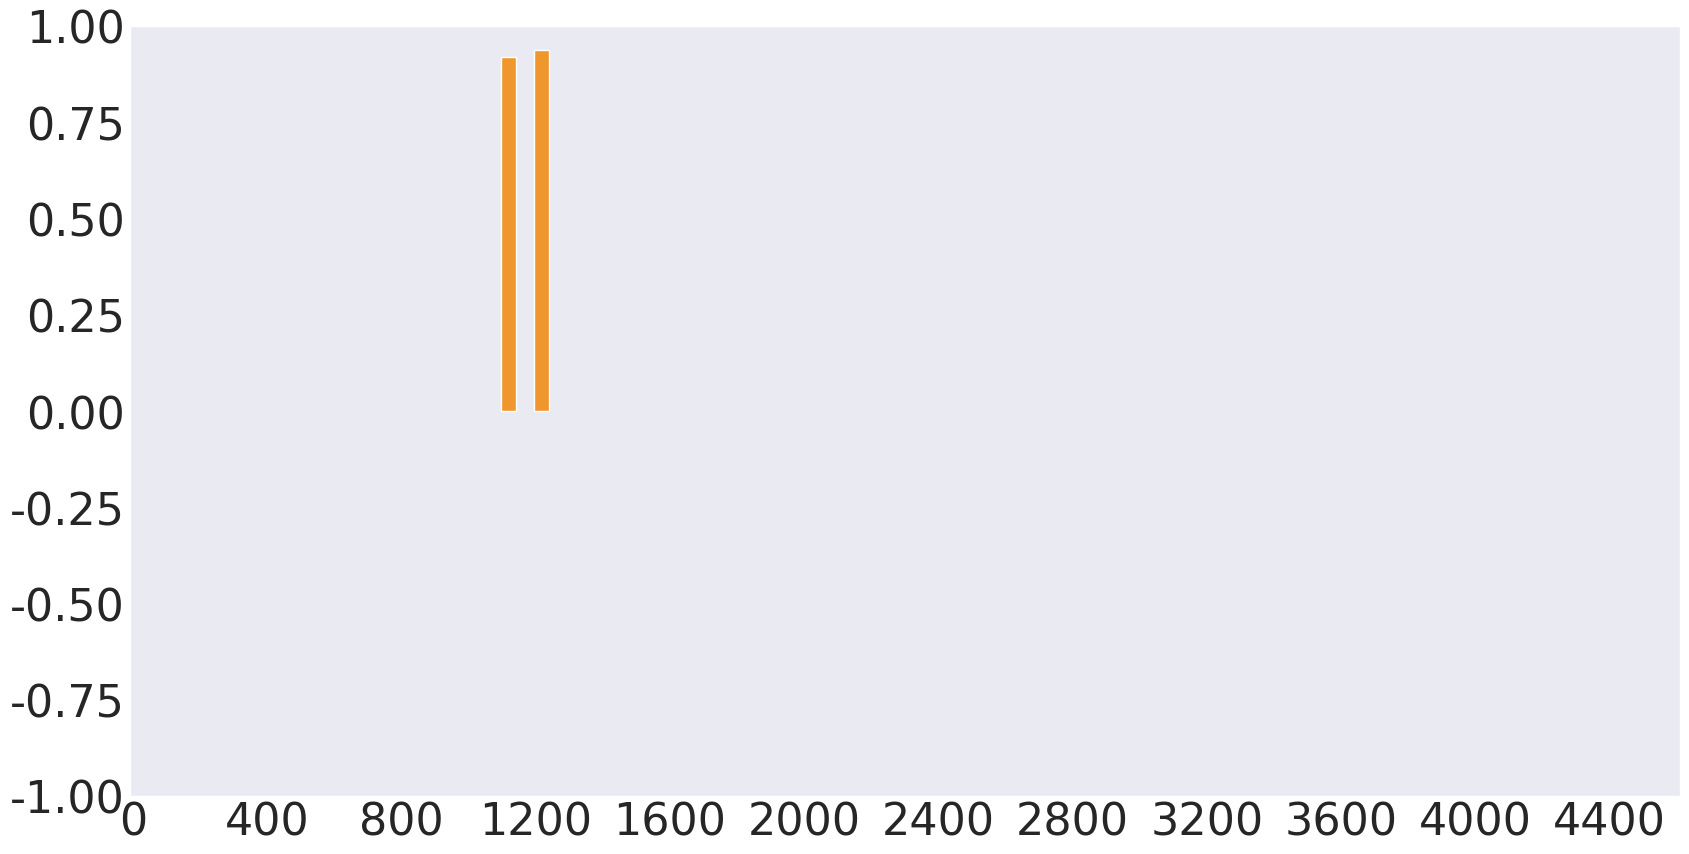

In [109]:
plot("NM_001161546", colour="dynamic")

NM_001069


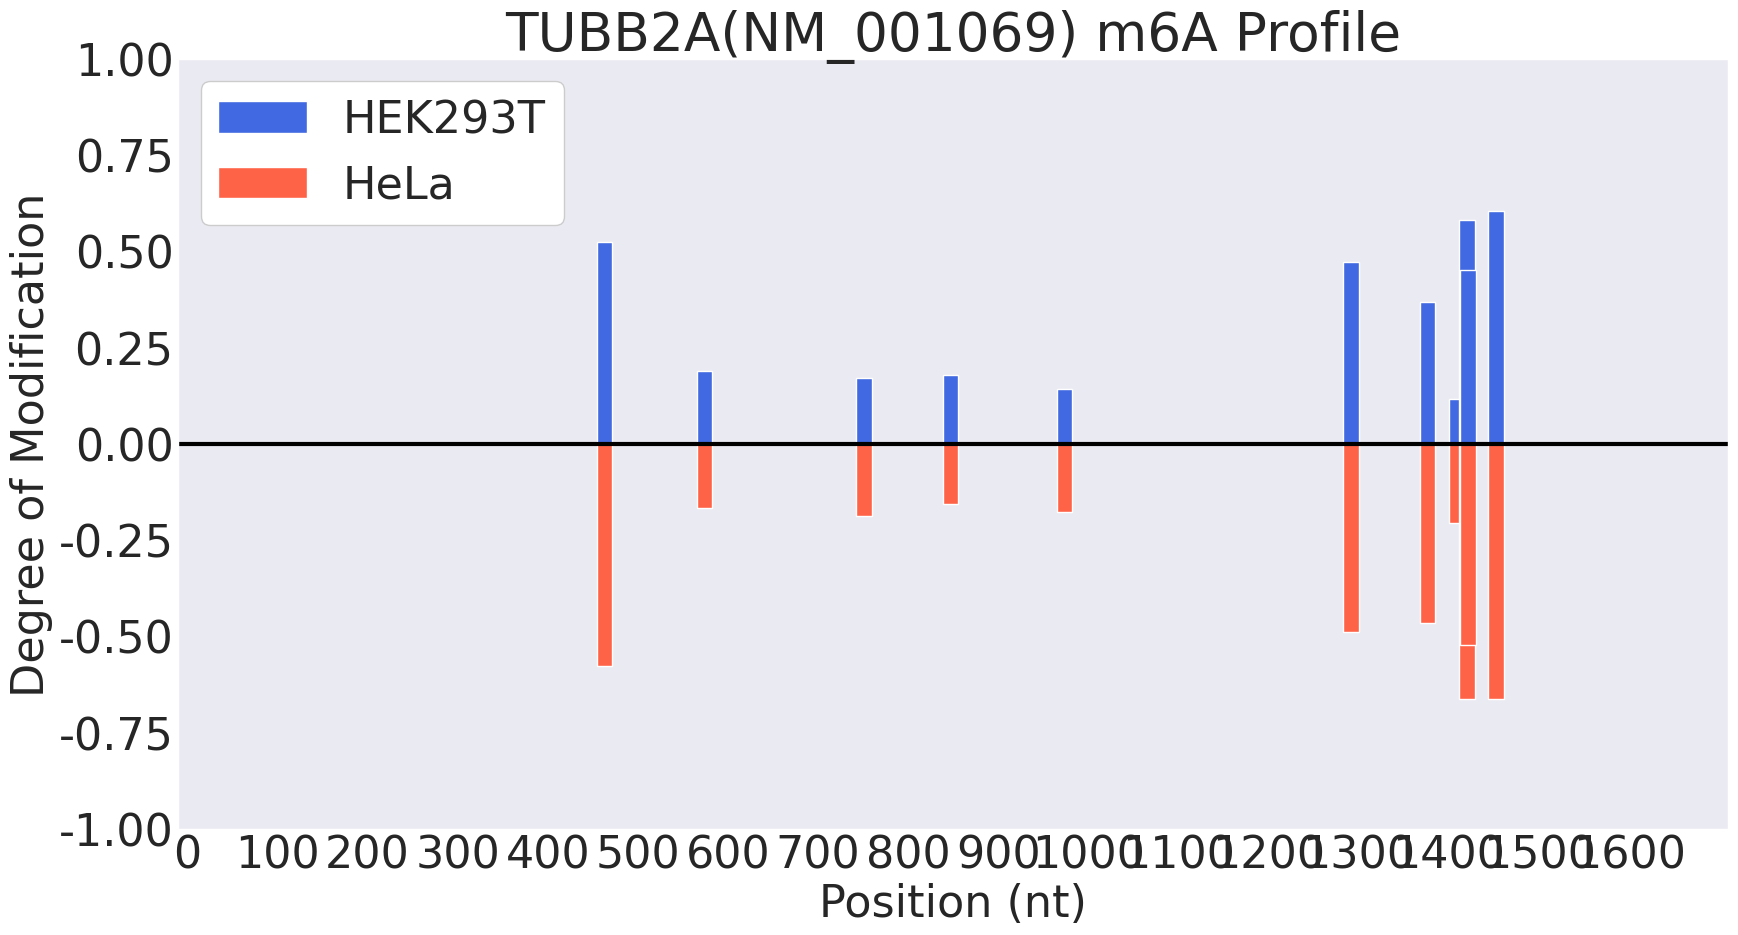

In [105]:
plot("NM_001069")

NM_004761


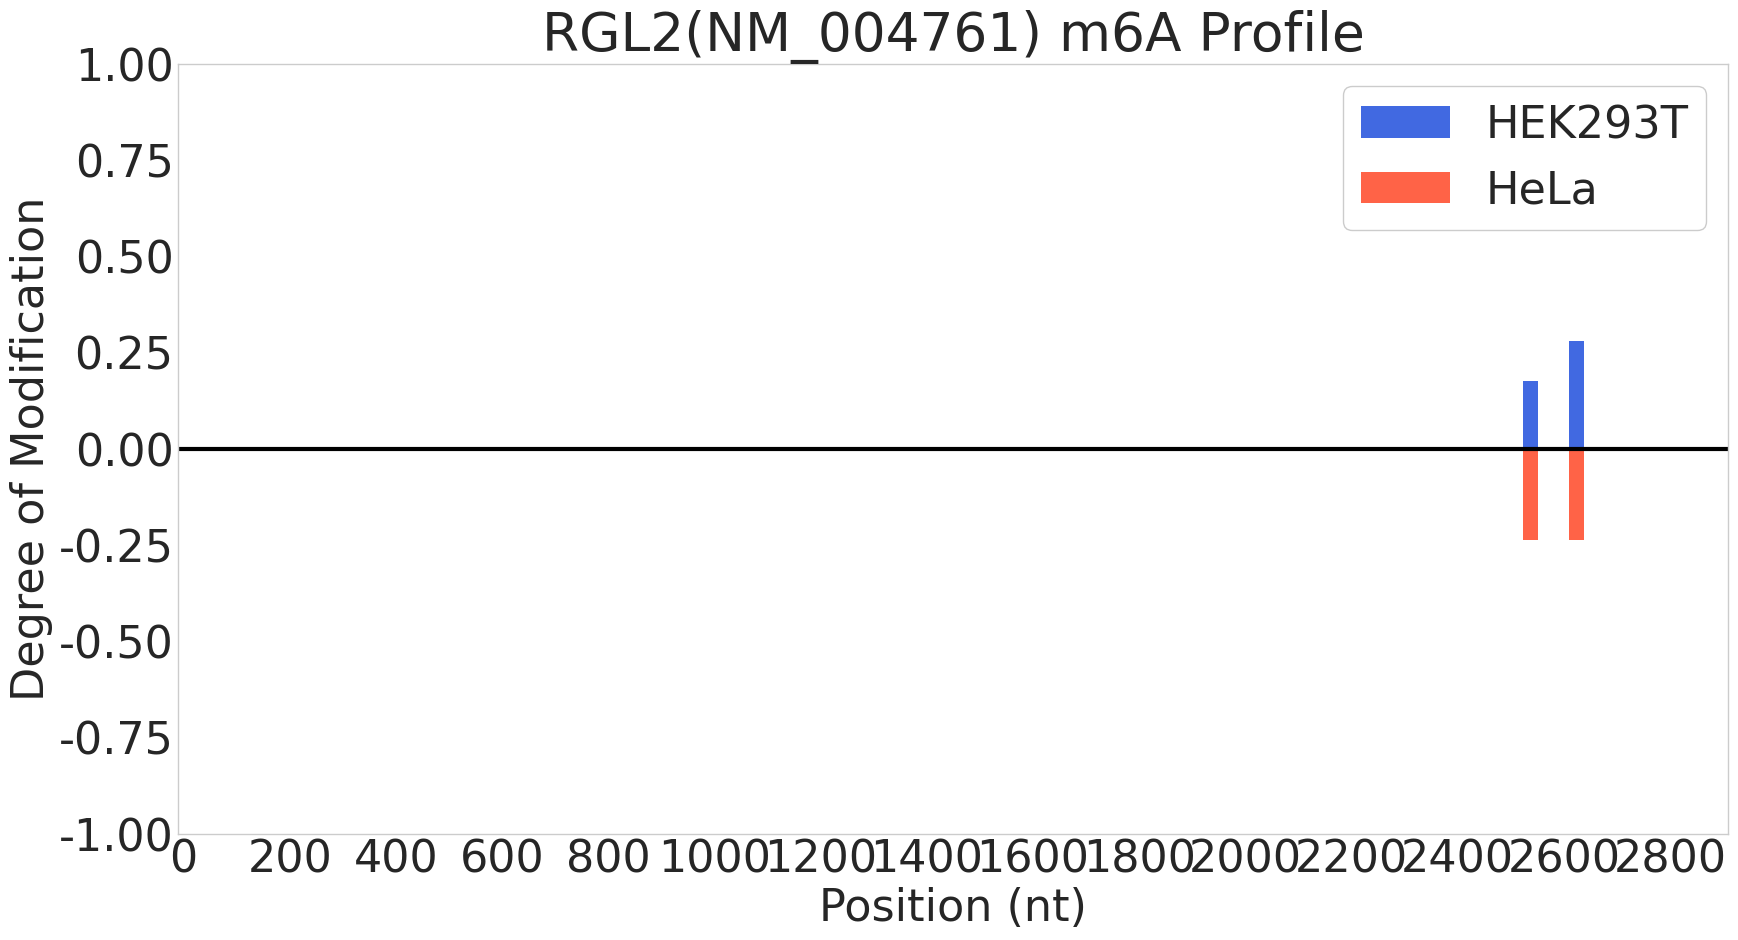

In [812]:
plot("NM_004761")

In [904]:
## Count DRACH and non-DRACH in GLORI

glori_df = "/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/glori_reformatted.tsv"
glori_df = pd.read_csv(glori_df, sep="\t")


In [905]:
print(glori_df)

          Chr Strand      Sites  m6A_level_rep1  m6A_level_rep2 chrstrand  \
0        chr9      +  134440485         0.69333         0.77922     chr9+   
1        chr9      +  134440485         0.69333         0.77922     chr9+   
2        chr9      +  134440485         0.69333         0.77922     chr9+   
3        chr9      -  137300014         0.78736         0.82895     chr9-   
4        chr9      -  137300274         0.62796         0.66242     chr9-   
...       ...    ...        ...             ...             ...       ...   
495172  chr17      +   48051150         0.91228         0.89783    chr17+   
495173  chr17      +   48051150         0.91228         0.89783    chr17+   
495174  chr17      +   48051197         0.34035         0.36547    chr17+   
495175  chr17      +   48051197         0.34035         0.36547    chr17+   
495176  chr17      +   48051197         0.34035         0.36547    chr17+   

                NMID  transcript_coordinate  
0          NM_002957         

In [912]:
import re

def is_drach(seq):
    seq = seq.upper()
    if re.search(r'[AGUT][AG]AC[ACUT]', seq):
        return True
    else:
        return False

In [913]:

glori_df["drach"] = glori_df["seq"].apply(is_drach)

In [919]:
glori_df_drach = glori_df.groupby(["chrstrand","Sites"]).agg({"drach": "max"})
print(glori_df_drach)

                    drach
chrstrand Sites          
chr1+     827634    False
          841506     True
          841558     True
          841599     True
          841882    False
...                   ...
chrY+     12839999  False
          12918210   True
          25482976   True
          25483299   True
          25483361   True

[130890 rows x 1 columns]


In [920]:
print(glori_df_drach["drach"].value_counts())

drach
True     112787
False     18103
Name: count, dtype: int64


In [921]:
print(18103/(18103+112787))

0.13830697532279013


In [923]:

x = 28038 + 19760 + 16267 + 15841 + 15596 + 12374 + 8253  + 6291  + 6079  + 6034  + 3699  + 3648  + 2893  + 2739 
print(x)

147512


In [925]:
print(28038/170240)

0.1646968984962406


In [933]:
genomic_fasta = "/extdata3/baeklab/Hyeonseo/m6A/res/ref/GCF_000001405.40_GRCh38.p14_genomic.fna"
genomic_fasta = SeqIO.to_dict(SeqIO.parse(genomic_fasta, "fasta"))

In [957]:
glori_df = "/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/glori_m6a.tsv"
glori_df = pd.read_csv(glori_df, sep="\t")
print(glori_df)

          Chr     Sites Strand          Gene  AGCov_rep1  AGCov_rep2  \
0       chr10     47499      -         TUBB8          76          65   
1       chr10   3835789      +          ELSE          33          31   
2       chr10   3899385      +          ELSE          60          57   
3       chr10   5357066      +          ELSE          65          53   
4       chr10   7596572      +          ELSE          28          30   
...       ...       ...    ...           ...         ...         ...   
170235   chrY  25307890      +       RPL41P6          27          33   
170236   chrY  25307971      +       RPL41P6          87          92   
170237   chrY  25308031      +       RPL41P6          36          38   
170238   chrY  25393262      -  LINC00265-3P          29          19   
170239   chrY  25393626      -  LINC00265-3P         213         211   

        m6A_level_rep1  m6A_level_rep2 Cluster_info  
0              0.30263         0.24615  Non-cluster  
1              0.69697     

In [950]:

def ncid_to_chr(ncid):
    ncid_int = int(ncid.split(".")[0][3:])
    if ncid_int <= 22:
        chr = f"chr{ncid_int}"
    elif ncid_int == 23:
        chr = "chrX"
    elif ncid_int == 24:
        chr = "chrY"
    elif ncid_int == 12920:
        chr = "chrM"
    else:
        chr = None
    return chr


In [952]:
genomic_fasta_dict = {}
for ncid in genomic_fasta:
    chr = ncid_to_chr(ncid)
    if chr:
        if chr not in genomic_fasta_dict:
            genomic_fasta_dict[chr] = genomic_fasta[ncid]
        else:
            raise ValueError(f"Duplicate chromosome {chr}")

print(genomic_fasta_dict.keys())

dict_keys(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY', 'chrM'])


In [954]:

def revcomp_DNA(seq):
    seq = seq.upper()
    basemap = dict(zip("ATUCG", "TAAGC"))
    if any([i not in basemap for i in seq]):
        raise None
    return "".join([basemap[i] for i in seq[::-1]])


In [958]:
glori_df["seq"] = glori_df.apply(lambda x: "".join(genomic_fasta_dict[x["Chr"]][x["Sites"]-3:x["Sites"]+2]), axis=1)
glori_df["seq"] = glori_df.apply(lambda x: revcomp_DNA(x["seq"]) if x["Strand"] == "-" else x["seq"].upper(), axis=1)
print(glori_df)

          Chr     Sites Strand          Gene  AGCov_rep1  AGCov_rep2  \
0       chr10     47499      -         TUBB8          76          65   
1       chr10   3835789      +          ELSE          33          31   
2       chr10   3899385      +          ELSE          60          57   
3       chr10   5357066      +          ELSE          65          53   
4       chr10   7596572      +          ELSE          28          30   
...       ...       ...    ...           ...         ...         ...   
170235   chrY  25307890      +       RPL41P6          27          33   
170236   chrY  25307971      +       RPL41P6          87          92   
170237   chrY  25308031      +       RPL41P6          36          38   
170238   chrY  25393262      -  LINC00265-3P          29          19   
170239   chrY  25393626      -  LINC00265-3P         213         211   

        m6A_level_rep1  m6A_level_rep2 Cluster_info    seq  
0              0.30263         0.24615  Non-cluster  GAACA  
1            

In [959]:

glori_df = glori_df[glori_df["seq"].notnull()]
print(glori_df)

          Chr     Sites Strand          Gene  AGCov_rep1  AGCov_rep2  \
0       chr10     47499      -         TUBB8          76          65   
1       chr10   3835789      +          ELSE          33          31   
2       chr10   3899385      +          ELSE          60          57   
3       chr10   5357066      +          ELSE          65          53   
4       chr10   7596572      +          ELSE          28          30   
...       ...       ...    ...           ...         ...         ...   
170235   chrY  25307890      +       RPL41P6          27          33   
170236   chrY  25307971      +       RPL41P6          87          92   
170237   chrY  25308031      +       RPL41P6          36          38   
170238   chrY  25393262      -  LINC00265-3P          29          19   
170239   chrY  25393626      -  LINC00265-3P         213         211   

        m6A_level_rep1  m6A_level_rep2 Cluster_info    seq  
0              0.30263         0.24615  Non-cluster  GAACA  
1            

In [960]:
glori_df["drach"] = glori_df["seq"].apply(is_drach)
print(glori_df["drach"].value_counts())

drach
True     145294
False     24946
Name: count, dtype: int64


In [961]:
print(sum(glori_df["drach"])/len(glori_df))

0.8534656954887218


In [182]:
files = glob.glob("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/GSE211303_hela.polya.wt.*")
etam_df = []
for file in files:
    etam_df.append(pd.read_csv(file, sep="\t"))
etam_df = pd.concat(etam_df)


In [183]:
print(etam_df)

                    pos  FTOm_total_count  ctrl_total_count           FDR  \
0         chr1_629218_+                44               197  1.907000e-02   
1         chr1_944103_+                43                17  2.524000e-02   
2        chr1_1055031_+               218               196  8.174000e-04   
3        chr1_1055080_+               225               179  2.483000e-47   
4        chr1_1055452_+               305               177  1.046000e-03   
...                 ...               ...               ...           ...   
15154  chrX_155054950_+                68               289  8.471000e-03   
15155  chrX_155054962_+                50               200  8.837000e-03   
15156  chrX_155121671_+                62                12  1.910000e-09   
15157  chrX_155239367_+               230               213  1.379000e-13   
15158   chrY_24362107_-                34                90  1.345000e-11   

       accessbility  methylation  motif motif_type  
0          100.0000   

In [184]:
etam_df = etam_df.groupby("pos")
df = []
for pos, group in tqdm.tqdm(etam_df):
    if len(group) == 1:
        df.append(group)
    else:
        ## select row with highest ctrl_total_count
        idx = group["ctrl_total_count"].idxmax()
        df.append(group.loc[[idx]])
etam_df = pd.concat(df)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 77001/77001 [00:21<00:00, 3532.99it/s]


In [186]:
etam_df = etam_df.reset_index(drop=True)
print(etam_df)

                     pos  FTOm_total_count  ctrl_total_count           FDR  \
0      chr10_100150475_-               159               124  3.623000e-07   
1      chr10_100150834_-               196               126  1.308000e-03   
2      chr10_100151360_-               187                99  4.238000e-11   
3      chr10_100151460_-               162                95  4.406000e-29   
4      chr10_100151528_-               243               124  1.811000e-22   
...                  ...               ...               ...           ...   
77000    chrY_57128660_+                32               132  5.385000e-03   
77001     chrY_7443458_-                63               179  3.423000e-02   
77002     chrY_7499121_-                10                83  3.726000e-04   
77003     chrY_8256973_+                15                41  1.815000e-02   
77004     chrY_8256981_+                14                39  1.560000e-02   

       accessbility  methylation  motif motif_type  
0         

In [187]:
etam_df.to_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/etam_m6a.tsv", sep="\t", index=False)

In [188]:
etam_df["chr"] = etam_df["pos"].str.split("_").str[0]
etam_df["strand"] = etam_df["pos"].str.split("_").str[2]
etam_df["pos"] = etam_df["pos"].str.split("_").str[1].astype(int)
print(etam_df)

             pos  FTOm_total_count  ctrl_total_count           FDR  \
0      100150475               159               124  3.623000e-07   
1      100150834               196               126  1.308000e-03   
2      100151360               187                99  4.238000e-11   
3      100151460               162                95  4.406000e-29   
4      100151528               243               124  1.811000e-22   
...          ...               ...               ...           ...   
77000   57128660                32               132  5.385000e-03   
77001    7443458                63               179  3.423000e-02   
77002    7499121                10                83  3.726000e-04   
77003    8256973                15                41  1.815000e-02   
77004    8256981                14                39  1.560000e-02   

       accessbility  methylation  motif motif_type    chr strand  
0          100.0000      33.9370  GAACU      DRACH  chr10      -  
1           87.6070      

In [189]:
etam_df.to_csv("/extdata3/baeklab/Hyeonseo/m6A/res/m6asites/etam_m6a.tsv", sep="\t", index=False)

In [194]:
## Get CDF of binomial distribution of 1000 coin tosses
from scipy import stats

n = 1000
p = 0.5
x = np.arange(0, n+1)
integral = 1-np.sum(stats.binom.pmf(x, n, p)[494:507])
print(integral)

0.6810229832764894
